In [ ]:
#TODO: Pass all of this into separated functions -> Cleaner to work with;

In [1]:
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from db_reader import dataframe_creator
from transformations import nature_encode
from plots import plot_heatmap
from utils import read_json
from models_opt import OptimizeRegressor


ModuleNotFoundError: No module named 'db_reader'

# 1. Data Cleaning

### 1.1 Load Data

Os dados devem ser carregados de uma base de dados, preferencialmente SQLite. Para isso, uma função de conexão entre a Base de Dados e o Notebook deve ser feita. A mesma pode igualmente ser implementada em uma função a parte ou em uma célula do notebook;

In [2]:
df = dataframe_creator();

NameError: name 'dataframe_creator' is not defined

O dataset consiste em dados de 47 estados (prefectures) do Japão de 2005 até 2019.

In [3]:
#TODO: Download dataset from Kagglehub
#Comment: There are about 47 files still missing for download
#TODO: Create function that saves the csv -> SQLite into SQLite; 

# === DOWNLOAD DATASET FROM KAGGLE ===
# I changed the old code because it was downloading the dataset every time i ran the notebook, which is not necessary and takes a lot of time. 
# Now it checks if the dataset is already downloaded before trying to download it again.
# I saved the files in a folder called "datasets" in the root of the project.

# pip install kaggle to be able to run below lines
import os
output_path = "../datasets"

if not os.path.exists(os.path.join(output_path, "prefecture_code.csv")):
    os.system(f'kaggle datasets download -d nishiodens/japan-real-estate-transaction-prices -p "{output_path}" --unzip')
else:
    print("Dataset already downloaded.")

Dataset already downloaded.


In [3]:
# Creating the pandas dataframes
prefecture_code_df = pd.read_csv("../datasets/prefecture_code.csv")

prefectures = {}
for i in range(1, 48):
    file_name = f"{i:02d}.csv"  # 01.csv, 02.csv, ..., 47.csv
    path = f"../datasets/trade_prices/{file_name}"
    prefectures[f"prefecture_{i:02d}"] = pd.read_csv(path, low_memory=False)

Além dos datasets individuais para cada prefecture, vou criar um dataset que junta tudo para algumas análises 

In [4]:
df_all = pd.concat(prefectures.values(), ignore_index=True)

### 1.2 Exploratory Data Analysis

In [5]:
#TODO: Perform some exploratory analysis over colum names, data types, proportions, duplicates, some plots

print("===== VISÃO GERAL DO DATASET =====")
print(f"Número total de instâncias: {df_all.shape[0]}")
print(f"Número total de atributos: {df_all.shape[1]}")
print()
#print(df_all.head())

print("=== Prefecture Code Dataframe ===")
print(f"Número de instâncias: {prefecture_code_df.shape[0]}")
print(f"Número total de atributos (incluindo classe): {prefecture_code_df.shape[1]}")
print()
#print(prefecture_code_df.head())

===== VISÃO GERAL DO DATASET =====
Número total de instâncias: 3906518
Número total de atributos: 38

=== Prefecture Code Dataframe ===
Número de instâncias: 47
Número total de atributos (incluindo classe): 3



#### 1.2.1 Descrição das colunas

##### Identificação e localização

- **No**: Identificador único da transação.  
- **Type**: Tipo de imóvel (ex: terreno, residencial, etc.).  
- **Region**: Região geral onde o imóvel está localizado.  
- **MunicipalityCode**: Código oficial do município.  
- **Prefecture**: Nome da prefeitura (similar a estado no Japão).  
- **Municipality**: Nome da cidade ou município.  
- **DistrictName**: Nome do distrito ou bairro.  
- **NearestStation**: Estação de transporte mais próxima.  
- **TimeToNearestStation**: Tempo até a estação mais próxima (categoria).  
- **MinTimeToNearestStation**: Tempo mínimo estimado até a estação (minutos).  
- **MaxTimeToNearestStation**: Tempo máximo estimado até a estação (minutos).  

##### Informações de preço

- **TradePrice**: Preço total da transação em Yen.  
- **UnitPrice**: Preço por unidade de área.  
- **PricePerTsubo**: Preço por *tsubo* (unidade tradicional japonesa de área).  

##### Características do imóvel

- **FloorPlan**: Planta do imóvel. Funciona em código para descrever a planta do imóvel: [Número][L][D][K] + extras (S)
    - L = Living room (sala de estar)
    - D = Dining room (sala de jantar)
    - K = Kitchen (cozinha)
    - R = Room (kitnet / studio)
    - S = Storage (depósito / quarto extra pequeno / escritório)
- **Area**: Área do imóvel (em m^2).  
- **AreaIsGreaterFlag**: Indica se a área é maior que 2000 m^2.  
- **LandShape**: Formato do terreno (retangular, trapézio, etc).  
- **Frontage**: Largura da frente do terreno (em metros).  
- **FrontageIsGreaterFlag**: Indica se a largura excede 2000 m^2.  
- **TotalFloorArea**: Área total construída.  
- **TotalFloorAreaIsGreaterFlag**: Indica se a área construída excede 2000 m^2.  


##### Construção

- **BuildingYear**: Ano de construção.  
- **PrewarBuilding**: Indica se o imóvel foi construído antes da guerra (1945).  
- **Structure**: Tipo de estrutura (madeira, concreto, etc.). 
    - SRC = Steel frame reinforced concrete, 
    - RC= Reinforced concrete, 
    - S = Steel frame, 
    - LS = Light steel structure, 
    - B = Concrete block, 
    - W = Wooden


##### Uso e planejamento

- **Use**: Uso atual do imóvel (casa, fábrica, loja, etc).  
- **Purpose**: Finalidade do terreno (planejamento urbano).  
- **Direction**: Direção da frente do imóvel.  
- **Classification**: Classificação da via/terreno.  
- **Breadth**: Largura da rua.  
- **CityPlanning**: Tipo de zoneamento urbano.  
- **CoverageRatio**: Taxa de ocupação do solo (%).  
- **FloorAreaRatio**: Índice de aproveitamento do terreno (%).  

##### Tempo e observações

- **Period**: Período da transação (ex: trimestre).  
- **Year**: Ano da transação.  
- **Quarter**: Trimestre da transação.  
- **Renovation**: Indica se houve reforma.  
- **Remarks**: Observações adicionais sobre o imóvel/transação.  

In [6]:
#print(df_all.columns)

categorical_columns = [
    'Type', 'Region', 'Prefecture', 'Municipality', 'DistrictName', 'NearestStation',
    'TimeToNearestStation', 'FloorPlan', 'LandShape', 'Structure', 'Use',
    'Purpose', 'Direction', 'Classification', 'CityPlanning', 'Period',
    'Renovation', 'Remarks'
]
numerical_columns = [
    'No', 'MunicipalityCode', 'MinTimeToNearestStation', 'MaxTimeToNearestStation',
    'TradePrice', 'Area', 'AreaIsGreaterFlag', 'UnitPrice', 'PricePerTsubo',
    'Frontage', 'FrontageIsGreaterFlag', 'TotalFloorArea',
    'TotalFloorAreaIsGreaterFlag', 'BuildingYear', 'PrewarBuilding', 'CoverageRatio', 'FloorAreaRatio', 
    'Breadth', 'Year', 'Quarter'
]

### Valores NaN

In [7]:
# TODO: define Nans treatment strategy (imputation, deletion, etc) and apply it to the dataset
df_all.isna().mean().round(2).sort_values(ascending=False)

Remarks                        0.94
Renovation                     0.86
FloorPlan                      0.85
Purpose                        0.70
TotalFloorArea                 0.66
UnitPrice                      0.65
PricePerTsubo                  0.65
BuildingYear                   0.52
Use                            0.52
Structure                      0.51
Frontage                       0.35
Breadth                        0.31
Classification                 0.31
Region                         0.29
Direction                      0.29
LandShape                      0.29
FloorAreaRatio                 0.18
CoverageRatio                  0.18
MaxTimeToNearestStation        0.17
MinTimeToNearestStation        0.15
TimeToNearestStation           0.15
NearestStation                 0.14
CityPlanning                   0.14
Municipality                   0.00
MunicipalityCode               0.00
Type                           0.00
No                             0.00
Prefecture                  

#### **Colunas em que mais de 50% dos valores são faltantes:**

| Column             | Missing % | Observações |
|--------------------|----------|-------------|
| Remarks            | 0.94     | Imóveis com observações especiais geralmente são atípicos (problemas legais, histórico especial, demolição programada).|

Os valores não NaN se referem a:

- "Dealings in which auction or arbiter participates": O imóvel não foi vendido em uma transação direta comum (vendedor-comprador). Ele passou por um leilão público ou por uma arbitragem/mediação (um terceiro, o árbitro, decidiu o valor ou as condições). Isso pode indicar que a venda for forçada, existe alguma disputa judicial etc. Seria um fator a impactar o preço do imóvel.
- "Dealings of adjacent land": A negociação envolve propriedades vizinhas que compartilham uma fronteira ou estão muito próximas. 
- "Dealings including special circumstances": A venda ocorreu em condições atípicas que podem ter afetado o preço, como venda entre parentes (preço abaixo do mercado), vendas urgentes, imóveis com ocupantes, ou situações que exigem disclosure (revelação) obrigatório por lei.
- "Dealings including private road": O acesso ao imóvel não é feito por uma rua pública mantida pela prefeitura, mas sim por uma "rua privada" (que pode ser uma estrada de terra, um condomínio fechado, ou um direito de passagem sobre terreno de terceiros).

Acredito que são informações importantes, mas são tão poucas que o melhor parece ser deletar a coluna. 




In [8]:
print(df_all['Remarks'].dropna().head(10))

16      Dealings of real estate that includes wound etc.
190    Dealings in which auction or arbiter participates
230                     Dealings between related objects
267    Dealings in which auction or arbiter participates
268    Dealings in which auction or arbiter participates
273             Dealings including special circumstances
361    Dealings in which auction or arbiter participates
502    Dealings in which auction or arbiter participates
510    Dealings in which auction or arbiter participates
536    Dealings in which auction or arbiter participates
Name: Remarks, dtype: object


In [9]:
df_all = df_all.drop('Remarks', axis=1)

| Column             | Missing % | Observações |
|--------------------|----------|-------------|
| Renovation         | 0.86     | imóveis sem registro de reforma podem ser terrenos, imóveis novos, ou casos onde a informação simplesmente não foi coletada. |

Muitos sem informação são apenas terrenos vazios, onde não faz sentido ocorrer uma reforma, podemos substituir por "Not applicable".

In [10]:
print(df_all.loc[df_all['Renovation'].isna(), 'Type'].value_counts())

#adicionando uma flag caso seja necessário no futuro
df_all['Renovation_known'] = df_all['Renovation'].notna().astype(int)

Type
Residential Land(Land and Building)    1405026
Residential Land(Land Only)            1384415
Agricultural Land                       335257
Forest Land                             163961
Pre-owned Condominiums, etc.             54463
Name: count, dtype: int64


In [11]:
print('=== Proporção de NaN em Renovation por tipo de terreno ===')
print(df_all.loc[df_all['Renovation'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que renovation está preenchido
print('\n === Proporção de casos preenchidos em Renovation por tipo de terreno ===')

group = df_all.groupby('Type')['Renovation']
renovation_by_type = group.agg(total='size', preenchidos='count')

porcentagem = renovation_by_type['preenchidos'] / renovation_by_type['total'] * 100

renovation_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(renovation_by_type)

=== Proporção de NaN em Renovation por tipo de terreno ===
Type
Residential Land(Land and Building)    42.0
Residential Land(Land Only)            41.4
Agricultural Land                      10.0
Forest Land                             4.9
Pre-owned Condominiums, etc.            1.6
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em Renovation por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859       563396              91.185
Residential Land(Land Only)          1384415            0               0.000
Residential Land(Land and Building)  1405026            0               0.000


In [12]:
# aplicando a nova regra 
land_types = ['Residential Land(Land Only)', 'Agricultural Land', 'Forest Land']

df_all.loc[df_all['Type'].isin(land_types), 'Renovation'] = 'Not Applicable'

# conferindo o resultado
df_all.loc[df_all['Renovation'].isna(), 'Type'].value_counts()

Type
Residential Land(Land and Building)    1405026
Pre-owned Condominiums, etc.             54463
Name: count, dtype: int64

In [13]:
# retirar terrenos da analise a partir de agora
df_buildings = df_all[(df_all['Type'] == 'Residential Land(Land and Building)') | (df_all['Type'] == 'Pre-owned Condominiums, etc.')]

# apos retirar os terrenos quantos nans restaram?
total = len(df_buildings)
nan_count = df_buildings['Renovation'].isna().sum()

print("Total imóveis com construção:", total)
print("NaN em Renovation:", round((nan_count / total) * 100, 1), "% (", nan_count, ") \n") #proporção de NaNs diminuiu 

Total imóveis com construção: 2022885
NaN em Renovation: 72.1 % ( 1459489 ) 



Será que imóveis novos tem mais NaNs em renovation? 

In [204]:
# Separar grupos
new = df_buildings[df_buildings['BuildingYear'] > 2010]
old = df_buildings[df_buildings['BuildingYear'] <= 2010]

# Ver proporção
print("Imóveis > 2010:", len(new))
print(new['Renovation'].value_counts(normalize=True, dropna=False).round(3))

print("\nImóveis <= 2010:", len(old))
print(old['Renovation'].value_counts(normalize=True, dropna=False).round(3))

Imóveis > 2010: 375616
Renovation
NaN        0.920
Not yet    0.072
Done       0.009
Name: proportion, dtype: float64

Imóveis <= 2010: 1494188
Renovation
NaN        0.652
Not yet    0.248
Done       0.100
Name: proportion, dtype: float64


Imoveis mais novos realmente possuem mais NaNs, mas ainda não é possível dizer se esses NaNs são "Not yet" ou "Unknown"...

Será que existe um padrão geográfico em renovation? Talvez alguma prefecture específica tenha mais NaNs?

Não consegui perceber um padrão geográfico.

In [205]:
# Conta quantos NaN existem por prefeitura
nan_counts = df_buildings[df_buildings['Renovation'].isna()].groupby('Prefecture').size()

# Conta o total de registros por prefeitura
total_counts = df_buildings.groupby('Prefecture').size()

# Calcula a proporção
geo = (nan_counts / total_counts).sort_values(ascending=False)

print(geo.head(10).round(2))

Prefecture
Aomori Prefecture       0.96
Nagano Prefecture       0.95
Kochi Prefecture        0.95
Yamanashi Prefecture    0.95
Shimane Prefecture      0.95
Yamagata Prefecture     0.95
Gifu Prefecture         0.95
Wakayama Prefecture     0.94
Akita Prefecture        0.94
Gunma Prefecture        0.93
dtype: float64


Será que existe algum padrão em relação à estrutura das casas? Estruturas mais antigas precisariam de reforma...

- Estruturas um pouco mais modernas:
    - SRC = Steel frame reinforced concrete, 
    - RC= Reinforced concrete, 
    - S = Steel frame, 
    - LS = Light steel structure, 
- Estruturas mais antigas
    - B = Concrete block, 
    - W = Wooden

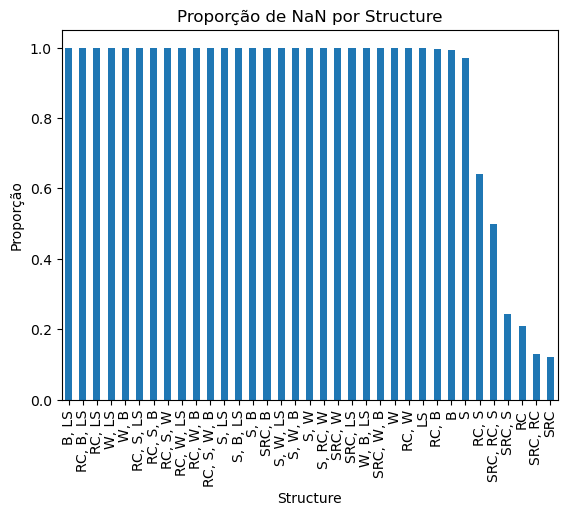

In [206]:
#print(df_buildings.groupby('Structure').size().sort_values(ascending=False))

# contar NaN por structure
nan_counts = df_buildings[df_buildings['Renovation'].isna()].groupby('Structure').size()

total_counts = df_buildings.groupby('Structure').size()
prop_nan = nan_counts / total_counts

prop_nan.sort_values(ascending=False).plot(kind='bar')
plt.title('Proporção de NaN por Structure')
plt.ylabel('Proporção')
plt.xticks(rotation=90)
plt.show()

Não consegui encontrar um padrão para imputar valores, deixo o resto como unknown ou como nan mesmo?

| Column             | Missing % | Observações |
|--------------------|----------|-------------|
| FloorPlan          | 0.85     | mostra quantos quartos/sala/cozinha etc tem no imóvel. |

No caso de terrenos vazios a informação de floorplan não é aplicável, vou fazer a mesma correção que anteriormente.

In [14]:
print('=== Proporção de NaN em FloorPlan por tipo de terreno ===')
print(df_all.loc[df_all['FloorPlan'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que floorplan está preenchido
print('\n === Proporção de casos preenchidos em FloorPlan por tipo de terreno ===')

group = df_all.groupby('Type')['FloorPlan']
floorplan_by_type = group.agg(total='size', preenchidos='count')

porcentagem = floorplan_by_type['preenchidos'] / floorplan_by_type['total'] * 100

floorplan_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(floorplan_by_type)

=== Proporção de NaN em FloorPlan por tipo de terreno ===
Type
Residential Land(Land and Building)    42.5
Residential Land(Land Only)            41.8
Agricultural Land                      10.1
Forest Land                             5.0
Pre-owned Condominiums, etc.            0.6
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em FloorPlan por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859       597170              96.652
Residential Land(Land Only)          1384415            0               0.000
Residential Land(Land and Building)  1405026            0               0.000


Será que floorplan é uma medida que só é feita em apartamentos? Todos os Residential Land(Land and Building) do dataset estão vazios

In [15]:
# aplicando a nova regra 
df_all.loc[df_all['Type'].isin(land_types), 'FloorPlan'] = 'Not Applicable'

| Column             | Missing % | Observações |
|--------------------|----------|-------------|
| Purpose            | 0.70     | The purpose of future use. For example, House, shop, office, factory, warehouse, and other. |

Avaliar melhor

In [18]:
print('=== Proporção de NaN em Purpose por tipo de terreno ===')
print(df_all.loc[df_all['Purpose'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que purpose está preenchido
print('\n === Proporção de casos preenchidos em Purpose por tipo de terreno ===')

group = df_all.groupby('Type')['Purpose']
purpose_by_type = group.agg(total='size', preenchidos='count')

porcentagem = purpose_by_type['preenchidos'] / purpose_by_type['total'] * 100

purpose_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(purpose_by_type)

=== Proporção de NaN em Purpose por tipo de terreno ===
Type
Residential Land(Land Only)            37.9
Residential Land(Land and Building)    30.7
Pre-owned Condominiums, etc.           13.3
Agricultural Land                      12.2
Forest Land                             5.9
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em Purpose por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257         3848               1.148
Forest Land                           163961         2447               1.492
Pre-owned Condominiums, etc.          617859       256686              41.544
Residential Land(Land Only)          1384415       352047              25.429
Residential Land(Land and Building)  1405026       567750              40.409


| Column             | Missing % | Observações |
|--------------------|----------|-------------|
| TotalFloorArea     | 0.66     |  |

Faz sentido não estar preenchido para forest, agricultural land e residential land only... agora, pq não esta preenchido em pre-owned condominiums?

"Pre-owned condominiums in Japan often do not display the "total floor area" (or gross area) because, unlike new builds, they are marketed using the Net Floor Area (Uchi-nori, 内法)" [(ref)](https://resources.realestate.co.jp/buy/senyou-menseki-%E5%B0%82%E7%94%A8%E9%9D%A2%E7%A9%8D-real-estate-japans-word-of-the-day/#:~:text=English%20definition:%20Exclusive%20floor%20area,wall%20perpendicular%20to%20the%20floor.)

"A term often confused with exclusive floor area is total floor area (延床面積). Total floor area refers to the combined floor space of the entire building.
For example, in a three-story building, the total of the floor areas from the 1st to the 3rd floors constitutes the total floor area. Since it is calculated across all floors and includes common areas, this measurement is more relevant for detached houses than for single-floor apartments." ([ref](https://www.landhousing.co.jp/for-foreigner/column/54))

In [19]:
print('=== Proporção de NaN em TotalFloorArea por tipo de terreno ===')
print(df_all.loc[df_all['TotalFloorArea'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que purpose está preenchido
print('\n === Proporção de casos preenchidos em TotalFloorArea por tipo de terreno ===')

group = df_all.groupby('Type')['TotalFloorArea']
totalfloorarea_by_type = group.agg(total='size', preenchidos='count')

porcentagem = totalfloorarea_by_type['preenchidos'] / totalfloorarea_by_type['total'] * 100

totalfloorarea_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(totalfloorarea_by_type)

=== Proporção de NaN em TotalFloorArea por tipo de terreno ===
Type
Residential Land(Land Only)            53.5
Pre-owned Condominiums, etc.           23.9
Agricultural Land                      12.9
Forest Land                             6.3
Residential Land(Land and Building)     3.4
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em TotalFloorArea por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859            0               0.000
Residential Land(Land Only)          1384415            0               0.000
Residential Land(Land and Building)  1405026      1317660              93.782


| Column             | Missing % | Observações |
|--------------------|----------|-------------|
| UnitPrice          | 0.65     | Unit Land Price(Yen) per m^2 |
| PricePerTsubo      | 0.65     | Unit Land Price(Yen) per Tsubo. Tsubo is a japanese unit |

Acredito que essas colunas devem ser deletadas pelo risco de data leakage, pois ambas estão correlacionadas com a coluna trade price.

In [20]:
df_all = df_all.drop('UnitPrice', axis=1)
df_all = df_all.drop('PricePerTsubo', axis=1)

| Column             | Missing % | Observações |
|--------------------|----------|-------------|
| BuildingYear       | 0.52     | Construction Year of Building |

Terrenos vazios teriam valores de NaN pois não existem construções neles. Como a coluna é numérica não posso adicionar um "not applicable" e nem zero. Acredito que talvez seja melhor deixar como nan e tentar imputar o building year dos imóveis que tem construção.

In [22]:
print('=== Proporção de NaN em BuildingYear por tipo de terreno ===')
print(df_all.loc[df_all['BuildingYear'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que buildingyear está preenchido
print('\n === Proporção de casos preenchidos em BuildingYear por tipo de terreno ===')

group = df_all.groupby('Type')['BuildingYear']
buildingyear_by_type = group.agg(total='size', preenchidos='count')

porcentagem = buildingyear_by_type['preenchidos'] / buildingyear_by_type['total'] * 100

buildingyear_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(buildingyear_by_type)

#plt.hist(df_buildings['BuildingYear'].dropna(), bins=30)
#plt.xlabel('BuildingYear')
#plt.ylabel('Frequência')
#plt.title('Distribuição de BuildingYear')
#plt.show()

=== Proporção de NaN em BuildingYear por tipo de terreno ===
Type
Residential Land(Land Only)            68.0
Agricultural Land                      16.5
Forest Land                             8.1
Residential Land(Land and Building)     6.7
Pre-owned Condominiums, etc.            0.9
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em BuildingYear por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859       600333              97.163
Residential Land(Land Only)          1384415            0               0.000
Residential Land(Land and Building)  1405026      1269471              90.352


| Column             | Missing % | Observações |
|--------------------|----------|-------------|
| Use                | 0.52     | Current Usage. For example, House, office, shop, factory, warehouse, workshop, parking lot, and other |

Em maior parte zonas rurais estão com valores faltantes, sera melhor colocar como not applicable ou como "other"?

In [23]:
print('=== Proporção de NaN em Use por tipo de terreno ===')
print(df_all.loc[df_all['Use'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que use está preenchido
print('\n === Proporção de casos preenchidos em Use por tipo de terreno ===')

group = df_all.groupby('Type')['Use']
use_by_type = group.agg(total='size', preenchidos='count')

porcentagem = use_by_type['preenchidos'] / use_by_type['total'] * 100

use_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(use_by_type)

=== Proporção de NaN em Use por tipo de terreno ===
Type
Residential Land(Land Only)            68.5
Agricultural Land                      16.6
Forest Land                             8.1
Residential Land(Land and Building)     4.8
Pre-owned Condominiums, etc.            2.0
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em Use por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859       577978              93.545
Residential Land(Land Only)          1384415            0               0.000
Residential Land(Land and Building)  1405026      1308496              93.130


| Column             | Missing % | Observações |
|--------------------|----------|-------------|
| Structure          | 0.51     | material de construção |

Os que são terrenos vazios irei criar a categoria "not applicable"

In [24]:
print('=== Proporção de NaN em Structure por tipo de terreno ===')
print(df_all.loc[df_all['Structure'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que structure está preenchido
print('\n === Proporção de casos preenchidos em Structure por tipo de terreno ===')

group = df_all.groupby('Type')['Structure']
structure_by_type = group.agg(total='size', preenchidos='count')

porcentagem = structure_by_type['preenchidos'] / structure_by_type['total'] * 100

structure_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(structure_by_type)

=== Proporção de NaN em Structure por tipo de terreno ===
Type
Residential Land(Land Only)            69.4
Agricultural Land                      16.8
Forest Land                             8.2
Residential Land(Land and Building)     4.9
Pre-owned Condominiums, etc.            0.6
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em Structure por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859       605241              97.958
Residential Land(Land Only)          1384415            0               0.000
Residential Land(Land and Building)  1405026      1307332              93.047


In [215]:
# aplicando a nova regra 
df_all.loc[df_all['Type'].isin(land_types), 'Structure'] = 'Not Applicable'

#### **Colunas em que menos de 50% dos valores são faltantes:**

| Column                      | Missing % | Observações |
|-----------------------------|----------|-------------|
| Frontage                    | 0.35     | A testada é a largura da frente do terreno, ou seja, o limite entre o imóvel e a rua ou via pública. |

In [26]:
print('=== Proporção de NaN em Frontage por tipo de terreno ===')
print(df_all.loc[df_all['Frontage'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que frontage está preenchido
print('\n === Proporção de casos preenchidos em Frontage por tipo de terreno ===')

group = df_all.groupby('Type')['Frontage']
frontage_by_type = group.agg(total='size', preenchidos='count')

porcentagem = frontage_by_type['preenchidos'] / frontage_by_type['total'] * 100

frontage_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(frontage_by_type)

=== Proporção de NaN em Frontage por tipo de terreno ===
Type
Pre-owned Condominiums, etc.           45.1
Agricultural Land                      24.5
Forest Land                            12.0
Residential Land(Land Only)            10.5
Residential Land(Land and Building)     7.9
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em Frontage por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859            0               0.000
Residential Land(Land Only)          1384415      1240868              89.631
Residential Land(Land and Building)  1405026      1296195              92.254


Se entendi certo, Pre-owned Condominiums são apartamentos, nesses casos o valor de frontage não se aplica. Acredito que de para substituir por zero, já que não há frontage. O mesmo para terrenos rurais

In [27]:
df_all.loc[df_all['Type'].isin(["Pre-owned Condominiums, etc."]), 'Frontage'] = 0.0

tipos_rurais = ['Agricultural Land', 'Forest Land']
df_all.loc[df_all['Type'].isin(tipos_rurais), 'Frontage'] = 0.0

Para os outros casos daria para usar a mediana de frontage por município para imputar um valor?

In [28]:
# Comparação de frontage por prefecture/municipality/districtname

tipos_com_frontage = ['Residential Land(Land Only)', 'Residential Land(Land and Building)']
mask = df_all['Type'].isin(tipos_com_frontage) & df_all['Frontage'].notna()

df_check = df_all[mask]

print("=== Variação da MEDIANA por nível geográfico ===\n")

# Por Prefecture
median_pref = df_check.groupby('Prefecture')['Frontage'].median()
print(f"Por Prefecture:   média={median_pref.mean():.1f}  std={median_pref.std():.2f}  min={median_pref.min():.1f}  max={median_pref.max():.1f}")

# Por Municipality
median_muni = df_check.groupby('Municipality')['Frontage'].median()
print(f"Por Municipality: média={median_muni.mean():.1f}  std={median_muni.std():.2f}  min={median_muni.min():.1f}  max={median_muni.max():.1f}")

# Por DistrictName
median_dist = df_check.groupby('DistrictName')['Frontage'].median()
print(f"Por DistrictName: média={median_dist.mean():.1f}  std={median_dist.std():.2f}  min={median_dist.min():.1f}  max={median_dist.max():.1f}")

=== Variação da MEDIANA por nível geográfico ===

Por Prefecture:   média=13.4  std=1.99  min=8.0  max=16.0
Por Municipality: média=15.0  std=3.93  min=5.5  max=36.5
Por DistrictName: média=16.3  std=8.87  min=0.5  max=50.0


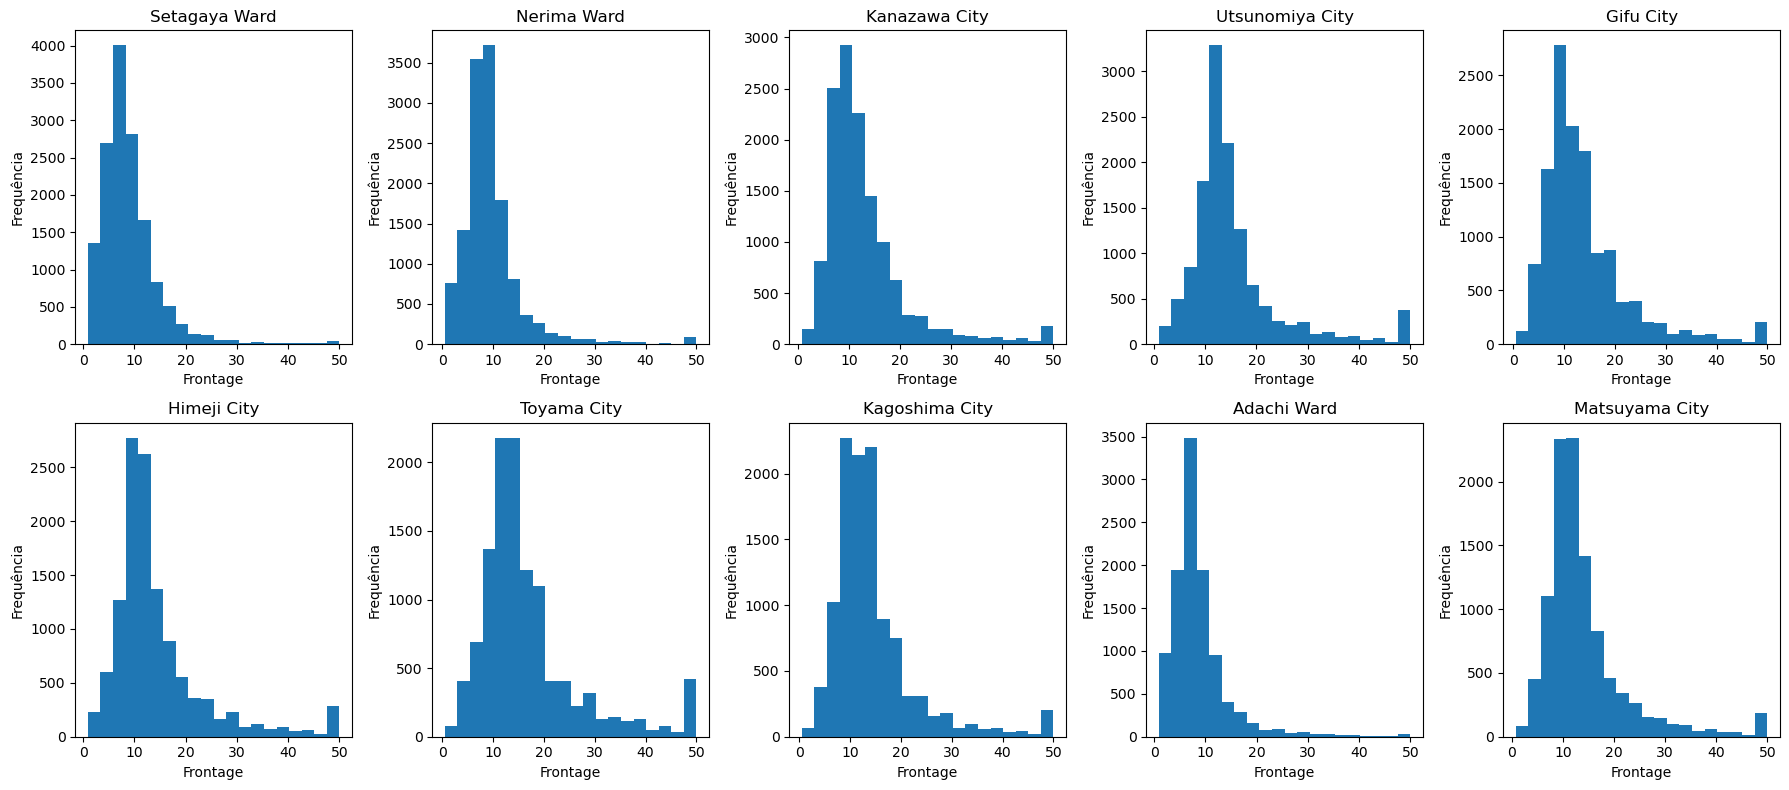

In [ ]:
# Selecionar 10 municípios com mais dados
top_municipios = df_check['Municipality'].value_counts().head(10).index

# Criar figura com 10 subplots (2 linhas x 5 colunas)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, muni in enumerate(top_municipios):
    dados = df_check[df_check['Municipality'] == muni]['Frontage']
    
    axes[i].hist(dados, bins=20)
    axes[i].set_title(muni)
    axes[i].set_xlabel('Frontage')
    axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

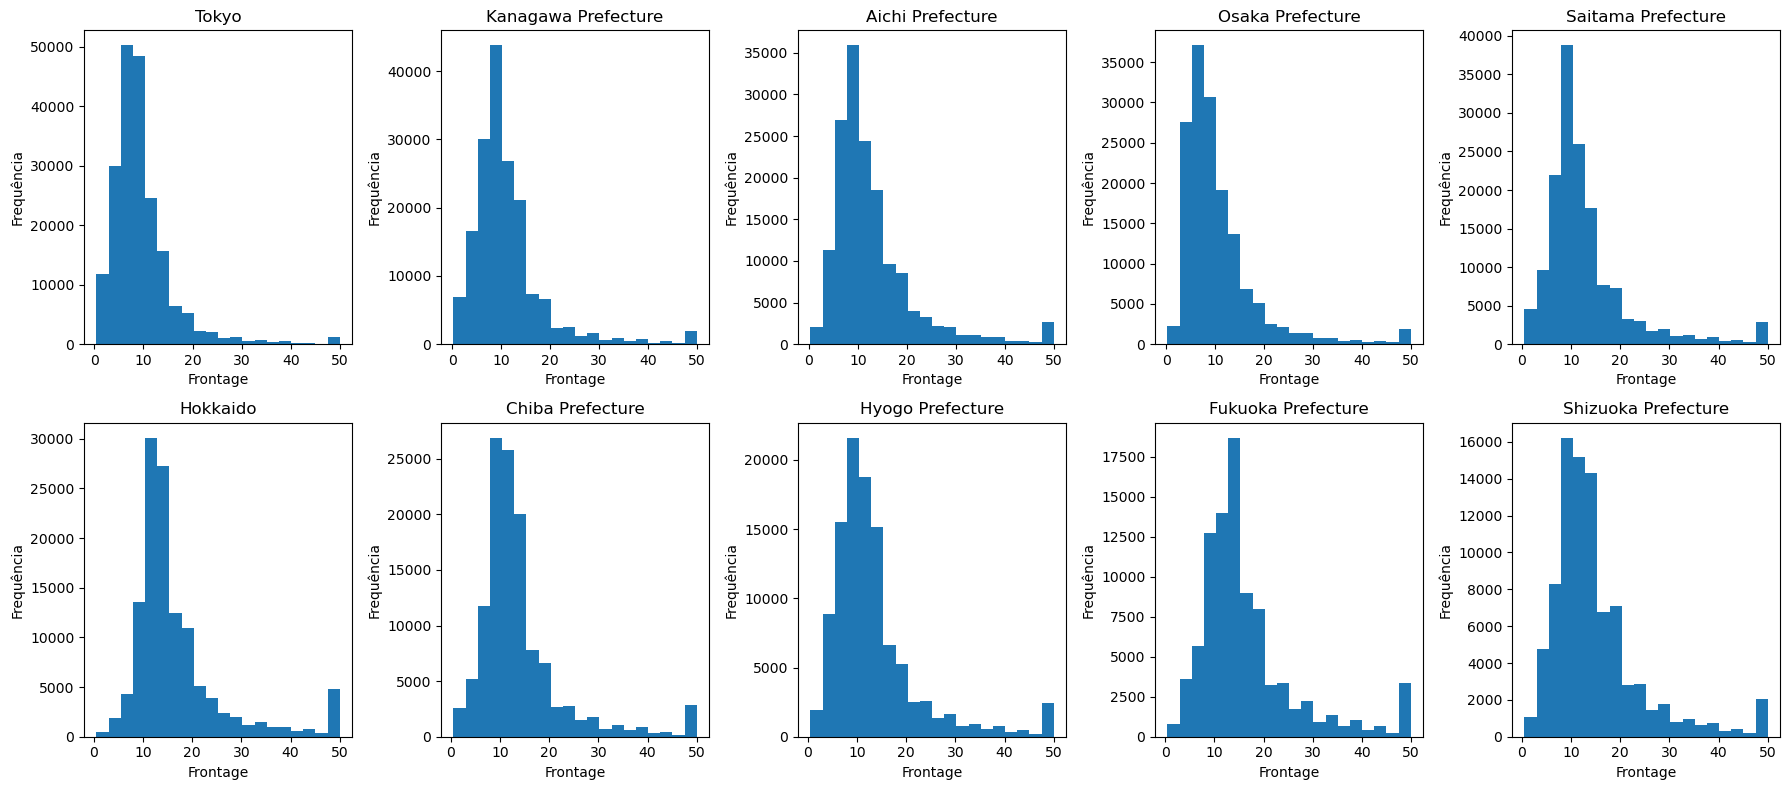

In [35]:
# Selecionar 10 prefectures com mais dados
top_prefectures = df_check['Prefecture'].value_counts().head(10).index

# Criar figura com 10 subplots (2 linhas x 5 colunas)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, pref in enumerate(top_prefectures):
    dados = df_check[df_check['Prefecture'] == pref]['Frontage']
    
    axes[i].hist(dados, bins=20)
    axes[i].set_title(pref)
    axes[i].set_xlabel('Frontage')
    axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

In [ ]:
mask = df_all['Type'].isin(tipos_com_frontage)

# calcular a mediana por tipo de terreno em cada municipio? ou prefecture?
mediana_frontage = df_all[mask].groupby(['Municipality', 'Type'])['Frontage'].transform('median')

# aplicar a mediana para preencher os valores faltantes -- descomentar se decidir fazer isso
#df_all.loc[mask, 'Frontage'] = df_all.loc[mask, 'Frontage'].fillna(mediana_frontage)

| Column                      | Missing % | Observações |
|-----------------------------|----------|-------------|
| Breadth                     | 0.31     | Frontage road Breadth(m)|

Assim como no caso de frontage, como apartamentos não tem frontage, eles também não vão ter a medida de frontage road breadth. O mesmo para terrenos rurais.

In [36]:
print('=== Proporção de NaN em Breadth por tipo de terreno ===')
print(df_all.loc[df_all['Breadth'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que breadth está preenchido
print('\n === Proporção de casos preenchidos em Breadth por tipo de terreno ===')

group = df_all.groupby('Type')['Breadth']
breadth_by_type = group.agg(total='size', preenchidos='count')

porcentagem = breadth_by_type['preenchidos'] / breadth_by_type['total'] * 100

breadth_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(breadth_by_type)


=== Proporção de NaN em Breadth por tipo de terreno ===
Type
Pre-owned Condominiums, etc.           50.6
Agricultural Land                      27.5
Forest Land                            13.4
Residential Land(Land Only)             6.6
Residential Land(Land and Building)     1.9
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em Breadth por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859            0               0.000
Residential Land(Land Only)          1384415      1304148              94.202
Residential Land(Land and Building)  1405026      1381689              98.339


Vou aplicar a mesma regra de frontage, atribuindo zero para apartamentos e terrenos rurais

In [37]:
df_all.loc[df_all['Type'].isin(["Pre-owned Condominiums, etc."]), 'Breadth'] = 0.0
df_all.loc[df_all['Type'].isin(tipos_rurais), 'Breadth'] = 0.0

| Column                      | Missing % | Observações |
|-----------------------------|----------|-------------|
| Classification              | 0.31     | Frontage road Classification, por exemplo Road' 'City Road' 'Prefectural Road' etc. |

Assim como no caso de frontage e breadth, apartamentos e areas rurais também não vão ter valores para frontage road classification.

In [38]:
print('=== Proporção de NaN em Classification por tipo de terreno ===')
print(df_all.loc[df_all['Classification'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que classification está preenchido
print('\n === Proporção de casos preenchidos em Classification por tipo de terreno ===')

group = df_all.groupby('Type')['Classification']
classification_by_type = group.agg(total='size', preenchidos='count')

porcentagem = classification_by_type['preenchidos'] / classification_by_type['total'] * 100

classification_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(classification_by_type)

=== Proporção de NaN em Classification por tipo de terreno ===
Type
Pre-owned Condominiums, etc.           51.8
Agricultural Land                      28.1
Forest Land                            13.8
Residential Land(Land Only)             5.4
Residential Land(Land and Building)     0.9
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em Classification por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859            0               0.000
Residential Land(Land Only)          1384415      1320009              95.348
Residential Land(Land and Building)  1405026      1394446              99.247


Vou aplicar a mesma regra de frontage e breadth, mas como é uma coluna de valores categóricos, colocarei o valor "Not Applicable".

In [39]:
df_all.loc[df_all['Type'].isin(["Pre-owned Condominiums, etc."]), 'Classification'] = 'Not Applicable'
df_all.loc[df_all['Type'].isin(tipos_rurais), 'Classification'] = 'Not Applicable'

| Column                      | Missing % | Observações |
|-----------------------------|----------|-------------|
| Region                      | 0.29     | The characteristics of surrounding areas. Exemplo: Residential Area, Potential Residential Area, Commercial Area, Industrial Area |

Isso é Missing Not At Random (MNAR), o dado não existe por razões estruturais, não por falha de coleta.

Mesmo padrao de frontage, breadth e classification. Nesse caso, não acho que o melhor approach seja definir tudo como "not applicable", pois pre-owned condominiums são bem diferentes de forest land. 

Ideias:

- Criar uma categoria que diferencie esses casos, por exemplo:
    - Agricultural Land -> Region = "Not Applicable"
    - Forest Land -> Region = "Not Applicable"
    - Pre-owned Condominiums -> Region = "Unknown"
- Preencher o valor de region com o próprio type do terreno:
    - Agricultural Land -> Region = "Agricultural Area"
    - Forest Land -> Region = "Forest Area"
    - Pre-owned Condominiums -> Region = "Pre-owned Condominiums Area"


In [40]:
print('=== Proporção de NaN em Region por tipo de terreno ===')
print(df_all.loc[df_all['Region'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que classification está preenchido
print('\n === Proporção de casos preenchidos em Region por tipo de terreno ===')

group = df_all.groupby('Type')['Region']
region_by_type = group.agg(total='size', preenchidos='count')

porcentagem = region_by_type['preenchidos'] / region_by_type['total'] * 100

region_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(region_by_type)

=== Proporção de NaN em Region por tipo de terreno ===
Type
Pre-owned Condominiums, etc.    55.3
Agricultural Land               30.0
Forest Land                     14.7
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em Region por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0                 0.0
Forest Land                           163961            0                 0.0
Pre-owned Condominiums, etc.          617859            0                 0.0
Residential Land(Land Only)          1384415      1384415               100.0
Residential Land(Land and Building)  1405026      1405026               100.0


| Column                      | Missing % | Observações |
|-----------------------------|----------|-------------|
| Direction                   | 0.29     | Frontage road Direction |

Mesmo padrao das colunas anteriores. Acredito que o melhor tratamento seria:

- Agricultural Land -> Direction = "Not Applicable"
- Forest Land -> Direction = "Not Applicable"
- Pre-owned Condominiums -> Direction = "Not Applicable"
- Residential Land(Land Only) -> Direction = "Unknown"
- Residential Land(Land and Building) -> Direction = "Unknown"

In [41]:
print('=== Proporção de NaN em Direction por tipo de terreno ===')
print(df_all.loc[df_all['Direction'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que classification está preenchido
print('\n === Proporção de casos preenchidos em Direction por tipo de terreno ===')

group = df_all.groupby('Type')['Direction']
direction_by_type = group.agg(total='size', preenchidos='count')

porcentagem = direction_by_type['preenchidos'] / direction_by_type['total'] * 100

direction_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(direction_by_type)

=== Proporção de NaN em Direction por tipo de terreno ===
Type
Pre-owned Condominiums, etc.           54.7
Agricultural Land                      29.7
Forest Land                            14.5
Residential Land(Land Only)             0.7
Residential Land(Land and Building)     0.3
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em Direction por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859            0               0.000
Residential Land(Land Only)          1384415      1376336              99.416
Residential Land(Land and Building)  1405026      1401134              99.723


| Column                      | Missing % | Observações |
|-----------------------------|----------|-------------|
| LandShape                   | 0.29     | Não consigo imaginar uma forma de inputar isso... acho melhor criar a categoria Unknown|
| FloorAreaRatio              | 0.18     | Talvez inputar            |
| CoverageRatio               | 0.18     | Talvez inputar           |


| Column                      | Missing % | Observações |
|-----------------------------|----------|-------------|
| NearestStation              | 0.14     | estacao mais proxima do imovel |

Similar aos outros casos, tem muitos valores faltantes em terrenos rurais por não haver estações

In [226]:
print('=== Proporção de NaN em NearestStation por tipo de terreno ===')
print(df_all.loc[df_all['NearestStation'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que classification está preenchido
print('\n === Proporção de casos preenchidos em NearestStation por tipo de terreno ===')

group = df_all.groupby('Type')['NearestStation']
neareststation_by_type = group.agg(total='size', preenchidos='count')

porcentagem = neareststation_by_type['preenchidos'] / neareststation_by_type['total'] * 100

neareststation_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(neareststation_by_type)

=== Proporção de NaN em NearestStation por tipo de terreno ===
Type
Agricultural Land                      59.3
Forest Land                            29.0
Residential Land(Land Only)             7.3
Residential Land(Land and Building)     4.0
Pre-owned Condominiums, etc.            0.5
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em NearestStation por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859       615272              99.581
Residential Land(Land Only)          1384415      1343075              97.014
Residential Land(Land and Building)  1405026      1382360              98.387


In [227]:
df_all.loc[df_all['Type'].isin(['Agricultural Land', 'Forest Land']), 'NearestStation'] = 'Not Applicable'

| Column                      | Missing % | Observações |
|-----------------------------|----------|-------------|
| CityPlanning                | 0.14     | The use districts designated by the City Planning Act. Exemplos: Category I Exclusively Low-story Residential Zone', 'Urbanization Control Area', 'Category I Residential Zone' |

colocar como not applicable ou como 'Outside City Planning Area'? que é um dos valores existentes em city planning

In [228]:
print('=== Proporção de NaN em CityPlanning por tipo de terreno ===')
print(df_all.loc[df_all['CityPlanning'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que cityplanning está preenchido
print('\n === Proporção de casos preenchidos em CityPlanning por tipo de terreno ===')

group = df_all.groupby('Type')['CityPlanning']
cityplanning_by_type = group.agg(total='size', preenchidos='count')

porcentagem = cityplanning_by_type['preenchidos'] / cityplanning_by_type['total'] * 100

cityplanning_by_type['porcentagem_preenc'] = (porcentagem).round(3)

print(cityplanning_by_type)

=== Proporção de NaN em CityPlanning por tipo de terreno ===
Type
Agricultural Land                      63.2
Forest Land                            30.9
Pre-owned Condominiums, etc.            3.4
Residential Land(Land Only)             1.5
Residential Land(Land and Building)     1.0
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em CityPlanning por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land                           163961            0               0.000
Pre-owned Condominiums, etc.          617859       599636              97.051
Residential Land(Land Only)          1384415      1376691              99.442
Residential Land(Land and Building)  1405026      1399525              99.608


| Column                      | Missing % | Observações |
|-----------------------------|----------|-------------|
| MaxTimeToNearestStation     | 0.17     | Varios NaNs são casos em que o min time é 2H, nesses casos daria para colocar o max como 2H  |
| MinTimeToNearestStation     | 0.15     | Geralmente quando esse é NaN todos os outros também são |
| TimeToNearestStation        | 0.15     | O valor mostrado nessa coluna é repetido nas Min e Max time           |

In [229]:
print(df_all[['MinTimeToNearestStation', 'TimeToNearestStation', 'MaxTimeToNearestStation']].dropna().head(10))

   MinTimeToNearestStation TimeToNearestStation  MaxTimeToNearestStation
0                     28.0                   28                     28.0
1                     27.0                   27                     27.0
2                     20.0                   20                     20.0
3                     26.0                   26                     26.0
4                     23.0                   23                     23.0
5                     28.0                   28                     28.0
6                     28.0                   28                     28.0
7                     25.0                   25                     25.0
8                     29.0                   29                     29.0
9                     23.0                   23                     23.0


Como o valor da coluna TimeToNearest station é a repetição muitas vezes do min e max time, vou deletá-la.

In [ ]:
# deletando a coluna
df_all = df_all.drop('TimeToNearestStation', axis=1)

Existem alguns casos em que o mínimo é 120 minutos e o máximo simplesmente não foi informado.

In [232]:
print("=== MaxTimeToNearestStation depende de MinTimeToNearestStation? ===")
print(df_all.loc[df_all['MaxTimeToNearestStation'].isna(), ['MinTimeToNearestStation']].value_counts(dropna=False), "\n")

mask = df_all['MinTimeToNearestStation'] == 120

print(" === quando Min=120, o Max é SEMPRE NaN? ===")
print(df_all.loc[mask, 'MaxTimeToNearestStation'].isna().mean()) 

=== MaxTimeToNearestStation depende de MinTimeToNearestStation? ===
MinTimeToNearestStation
NaN                        590541
120.0                       87906
Name: count, dtype: int64 

 === quando Min=120, o Max é SEMPRE NaN? ===
1.0


Como estratégia para reduzir nans vou preencher Max com 120 onde Min já é 120

In [233]:
df_all.loc[mask, 'MaxTimeToNearestStation'] = 120

Também é relevante notar que algumas estações não terão medidas de tempo porque em terrenos de zonas rurais não tem estações próximas ou esse dado é sistematicamente não coletado.

In [234]:
print('=== Proporção de NaN em MinTimeToNearestStation por tipo de terreno ===')
print(df_all.loc[df_all['MinTimeToNearestStation'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

print('=== Proporção de NaN em MaxTimeToNearestStation por tipo de terreno ===')
print(df_all.loc[df_all['MaxTimeToNearestStation'].isna(), 'Type'].value_counts(dropna=False, normalize=True).round(3) * 100)

# para cada tipo de terreno, ver casos em que mintimetoneareststation está preenchido
print('\n === Proporção de casos preenchidos em MinTimeToNearestStation por tipo de terreno ===')

group = df_all.groupby('Type')['MinTimeToNearestStation']
mintimetoneareststation_by_type = group.agg(total='size', preenchidos='count')

porcentagem = mintimetoneareststation_by_type['preenchidos'] / mintimetoneareststation_by_type['total'] * 100
mintimetoneareststation_by_type['porcentagem_preenc'] = (porcentagem).round(3)
print(mintimetoneareststation_by_type)

# para cada tipo de terreno, ver casos em que maxtimetoneareststation está preenchido
print('\n === Proporção de casos preenchidos em MaxTimeToNearestStation por tipo de terreno ===')

group = df_all.groupby('Type')['MaxTimeToNearestStation']
maxtimetoneareststation_by_type = group.agg(total='size', preenchidos='count')
porcentagem = maxtimetoneareststation_by_type['preenchidos'] / maxtimetoneareststation_by_type['total'] * 100

maxtimetoneareststation_by_type['porcentagem_preenc'] = (porcentagem).round(3)
print(maxtimetoneareststation_by_type)

=== Proporção de NaN em MinTimeToNearestStation por tipo de terreno ===
Type
Agricultural Land                      56.8
Forest Land                            27.8
Residential Land(Land Only)             7.4
Residential Land(Land and Building)     4.1
Pre-owned Condominiums, etc.            3.9
Name: proportion, dtype: float64
=== Proporção de NaN em MaxTimeToNearestStation por tipo de terreno ===
Type
Agricultural Land                      56.8
Forest Land                            27.8
Residential Land(Land Only)             7.4
Residential Land(Land and Building)     4.1
Pre-owned Condominiums, etc.            3.9
Name: proportion, dtype: float64

 === Proporção de casos preenchidos em MinTimeToNearestStation por tipo de terreno ===
                                       total  preenchidos  porcentagem_preenc
Type                                                                         
Agricultural Land                     335257            0               0.000
Forest Land       

A questão é, que tempo colocar se não tem estações proximas? deixar vazio mesmo? 

Verificando quantos NaNs sobraram por coluna após as modificações feitas

In [235]:
df_all.isna().mean().round(2).sort_values(ascending=False)

Purpose                        0.70
TotalFloorArea                 0.66
Use                            0.52
BuildingYear                   0.52
Renovation                     0.37
FloorPlan                      0.36
LandShape                      0.29
Region                         0.29
Direction                      0.29
CoverageRatio                  0.18
FloorAreaRatio                 0.18
TimeToNearestStation           0.15
MaxTimeToNearestStation        0.15
MinTimeToNearestStation        0.15
CityPlanning                   0.14
Frontage                       0.06
Breadth                        0.03
Structure                      0.03
Classification                 0.02
NearestStation                 0.02
MunicipalityCode               0.00
Type                           0.00
No                             0.00
AreaIsGreaterFlag              0.00
DistrictName                   0.00
Municipality                   0.00
Prefecture                     0.00
TradePrice                  

### Verificando data types

In [51]:
pd.set_option('display.max_columns', None) # display all columns of the dataframe when printing

#columns names and data types
print("=== Prefecture Code Data Types ===")
print(prefecture_code_df.info())
print()

print("=== Prefecture 01 Data Types ===")
print(prefectures["prefecture_01"].info())
print()

=== Prefecture Code Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Code    47 non-null     int64 
 1   JpName  47 non-null     object
 2   EnName  47 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.2+ KB
None

=== Prefecture 01 Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186238 entries, 0 to 186237
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   No                           186238 non-null  int64  
 1   Type                         186238 non-null  object 
 2   Region                       133069 non-null  object 
 3   MunicipalityCode             186238 non-null  int64  
 4   Prefecture                   186238 non-null  object 
 5   Municipality                 186238 non-null  object 
 6   Distri

Columns that need adjustment

- **AreaIsGreaterFlag**  
  Contains 0 and 1 values, but is stored as object, should be converted to int or bool.

- **TotalFloorAreaIsGreaterFlag**  
  Contains 0 and 1 values, but is stored as object, should be converted to int or bool.

- **PrewarBuilding**  
  Contains 0 and 1 values, but is stored as object, should be converted to int or bool.

- **BuildingYear**  
  Stored as float, but represents a year, should be converted to int.

In [52]:
# Check the values of the columns to see if there are any inconsistent data types
#print(prefectures["prefecture_01"][prefectures["prefecture_01"]["AreaIsGreaterFlag"] != 0].head()) 
#print(prefectures["prefecture_01"][prefectures["prefecture_01"]["TotalFloorAreaIsGreaterFlag"] != 0].head()) 
#print(prefectures["prefecture_01"][prefectures["prefecture_01"]["TotalFloorAreaIsGreaterFlag"] != 0].head()) 
#print(prefectures["prefecture_01"][prefectures["prefecture_01"]["PrewarBuilding"] != 0].head()) 
#print(prefectures["prefecture_02"]["TimeToNearestStation"].head(10)) 
#print(prefectures["prefecture_01"]["BuildingYear"].head()) 
#print(prefectures["prefecture_01"]["MunicipalityCode"].head())
#print(prefectures["prefecture_01"]["DistrictName"].head())

# convert to correct data types
columns_to_convert = {
    "AreaIsGreaterFlag": int,
    "TotalFloorAreaIsGreaterFlag": int,
    "PrewarBuilding": int,
    "BuildingYear": int,
    "MunicipalityCode": str,
    "DistrictName": str
}

for df in prefectures.values():
    for col, tipo in columns_to_convert.items():
        df[col] = df[col].astype(tipo)

#df['DistrictName'] = df['DistrictName'].apply(lambda x: x.split(',')[0]) # remover os nomes depois da vírgula, caso contrário não é encontrada a localização

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

### 1.2 First NaN Treatment

In [4]:
df.isna().mean().sort_values(ascending=False)

Remarks                        0.921869
PricePerTsubo                  0.804457
UnitPrice                      0.804457
TotalFloorArea                 0.664453
Purpose                        0.612049
Renovation                     0.590479
FloorPlan                      0.561874
Frontage                       0.500985
Breadth                        0.464792
Classification                 0.461765
Direction                      0.455746
LandShape                      0.455692
Region                         0.454703
Use                            0.240755
BuildingYear                   0.226967
Structure                      0.216978
MaxTimeToNearestStation        0.025798
MinTimeToNearestStation        0.025430
TimeToNearestStation           0.025430
FloorAreaRatio                 0.014548
CoverageRatio                  0.014548
CityPlanning                   0.009410
NearestStation                 0.004250
DistrictName                   0.000605
Period                         0.000000


Como esperado, a coluna de anotações não tem muitos valores e por isso não impactará muito os resultados;

Removeremos as variáveis que têm muitos valores nulos, pois é pouco provável que recuperá-los tenha um impacto positivo no modelo;

In [5]:
# teste = df[~df["UnitPrice"].isnull()][["Area", "UnitPrice", "TradePrice"]] 
df = df.drop(columns=["Remarks", "UnitPrice", "PricePerTsubo"])

### 1.3 Data Types

In [6]:
df.dtypes.sort_values()

TradePrice                       int64
Year                             int64
MunicipalityCode                 int64
TotalFloorAreaIsGreaterFlag      int64
PrewarBuilding                   int64
Area                             int64
AreaIsGreaterFlag                int64
Quarter                          int64
BuildingYear                   float64
FloorAreaRatio                 float64
CoverageRatio                  float64
Breadth                        float64
MinTimeToNearestStation        float64
MaxTimeToNearestStation        float64
TotalFloorArea                 float64
Frontage                       float64
Type                            object
Classification                  object
CityPlanning                    object
Period                          object
Direction                       object
Purpose                         object
FrontageIsGreaterFlag           object
Structure                       object
LandShape                       object
FloorPlan                

In [7]:
df["MunicipalityCode"] = df["MunicipalityCode"].astype(str) # esta como int mas na verdade é categórico
df["DistrictName"] = df["DistrictName"].astype(str) 
df['DistrictName'] = df['DistrictName'].apply(lambda x: x.split(',')[0]) # remover os nomes depois da vírgula, caso contrário não é encontrada a localização

### 1.4. Outliers

In [8]:
df.describe()

,MinTimeToNearestStation,MaxTimeToNearestStation,TradePrice,Area,AreaIsGreaterFlag,Frontage,TotalFloorArea,TotalFloorAreaIsGreaterFlag,BuildingYear,PrewarBuilding,Breadth,CoverageRatio,FloorAreaRatio,Year,Quarter
count,396236.000000,396086.000000,4.065750e+05,406575.000000,406575.000000,202887.000000,136425.000000,406575.000000,314296.000000,406575.000000,217602.000000,400660.000000,400660.000000,406575.000000,406575.000000
mean,10.202352,11.132226,6.559070e+07,117.087425,0.003534,9.628389,172.495254,0.003015,1997.939315,0.000762,6.245105,62.130085,265.398517,2012.579836,2.500687
std,7.980606,11.628337,3.092895e+08,204.205609,0.059346,6.617539,267.770785,0.054830,14.106049,0.027602,4.868474,13.136797,159.670705,3.902094,1.119079
min,0.000000,0.000000,5.000000e+02,10.000000,0.000000,0.400000,10.000000,0.000000,1945.000000,0.000000,1.000000,30.000000,50.000000,2005.000000,1.000000
25%,5.000000,5.000000,2.100000e+07,50.000000,0.000000,5.900000,85.000000,0.000000,1988.000000,0.000000,4.000000,60.000000,150.000000,2009.000000,1.000000
50%,8.000000,8.000000,3.500000e+07,70.000000,0.000000,8.000000,95.000000,0.000000,2001.000000,0.000000,5.000000,60.000000,200.000000,2013.000000,3.000000
75%,13.000000,13.000000,5.400000e+07,115.000000,0.000000,11.300000,120.000000,0.000000,2009.000000,0.000000,6.000000,80.000000,300.000000,2016.000000,3.000000
max,120.000000,120.000000,6.100000e+10,5000.000000,1.000000,50.000000,2000.000000,1.000000,2020.000000,1.000000,90.000000,80.000000,1300.000000,2019.000000,4.000000


Não apresenta outliers:
* Datas estão entre 1945 - 2020;
* Flags estão entre 0 - 1;
* Tempos não passam de 120 minutos;
* Ratios estão entre 0% - 100%, com excessão de FloorAreaRatio, que pode ser maior;
* Não apresenta valores negativos;

# 2. Feature Engineering e Feature Selection

### 2.1. Numerical Variables

Heatmap pra ter um overview melhor das correlações entre as variáveis numéricas;

In [9]:
num_attributes = df.select_dtypes(include=['int64', 'float64'])

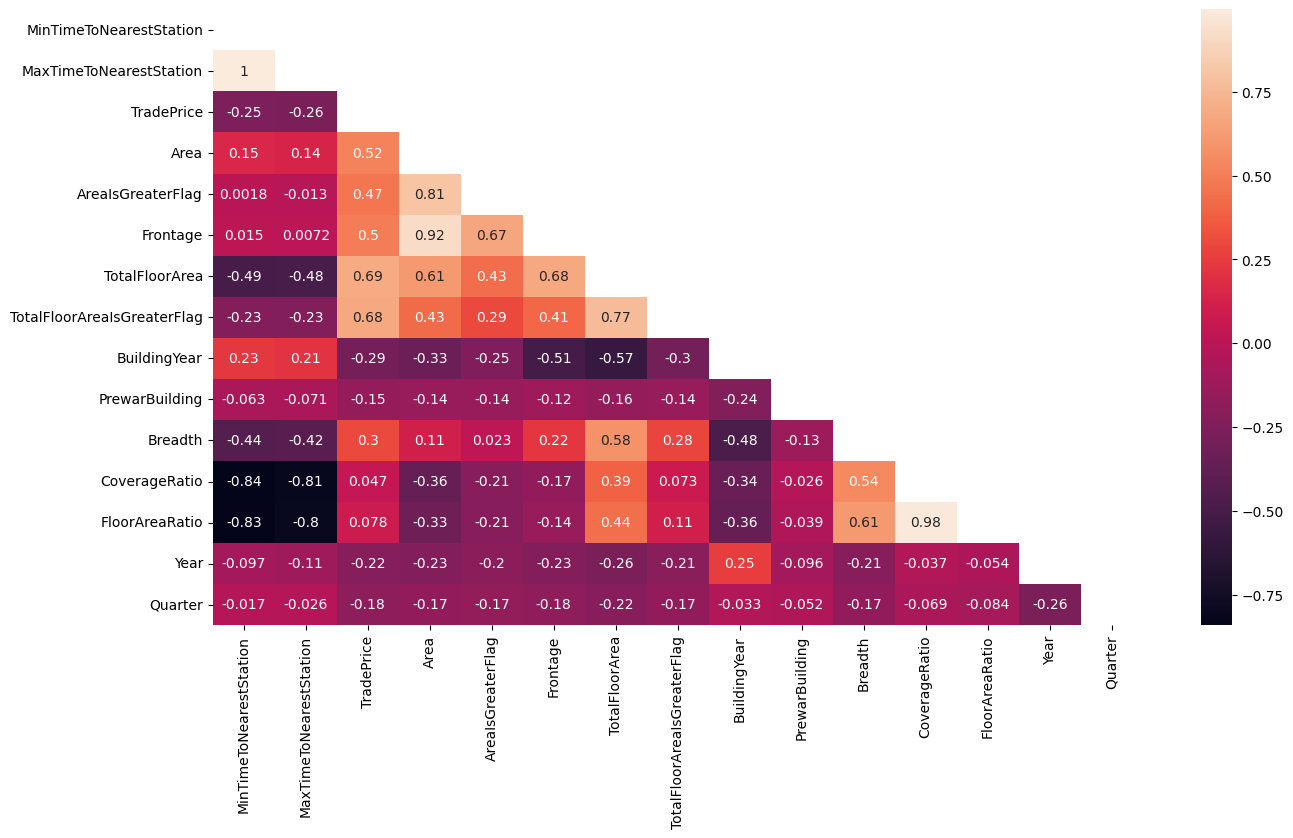

In [10]:
plot_heatmap(num_attributes)

Algumas observações interessantes que podem ser feitas em relação à variável TradePrice:
* Tamanho do imóvel (Area e TotalFloorArea) tem uma grande influência no preço;
* Largura da via de acesso ao imóvel influência no preço, indicando uma relação entre a acessibilidade e a valorização;
* Ano de construção do imóvel tem uma pequena correlação inversa com o preço, algo que parece contraditório. Geralmente se espera que imóveis mais novos sejam mais valorizados;
    * Isso pode acontecer por haver uma maior quantidade de prédios mais velhos que estão renovados e logo são valorizados por isso;
    * Vamos testar essa hipótese abaixo;

### Renovações por Ano

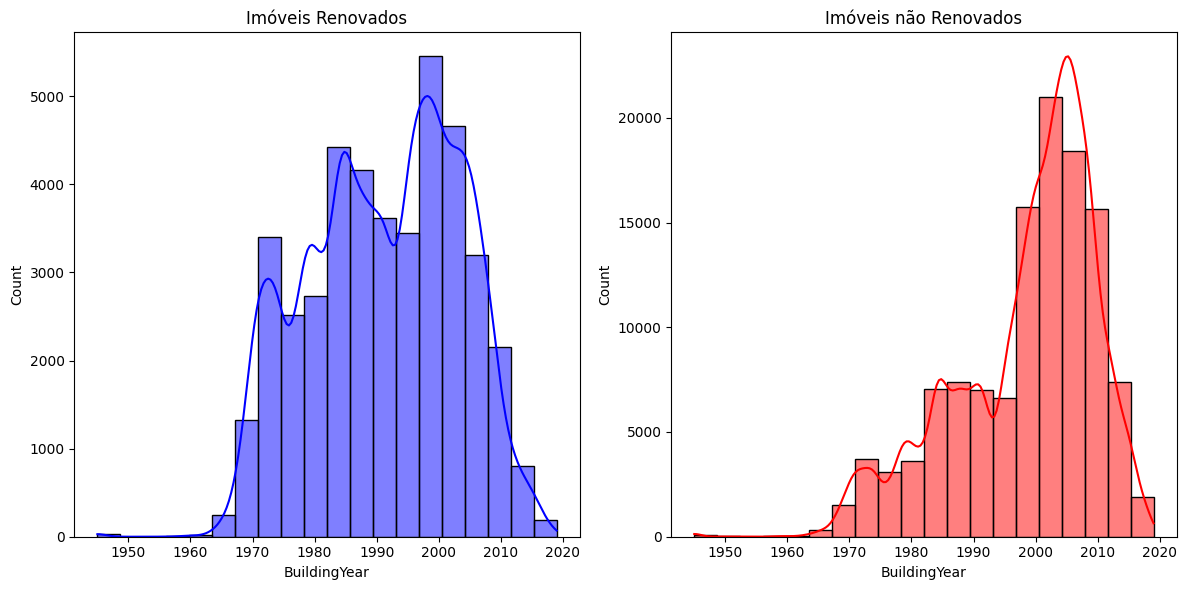

In [3]:
renewed = df.loc[df.Renovation == 'Done']
not_renewed = df.loc[df.Renovation == 'Not yet']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(data=renewed, x='BuildingYear', ax=axes[0], bins=20, color='blue', kde=True)
axes[0].set_title('Imóveis Renovados')

sns.histplot(data=not_renewed, x='BuildingYear', ax=axes[1], bins=20, color='red', kde=True)
axes[1].set_title('Imóveis não Renovados')

plt.tight_layout()
plt.show()

Podemos observar que uma significativa quantidade dos imóveis mais antigos que estão no mercado estão renovados;

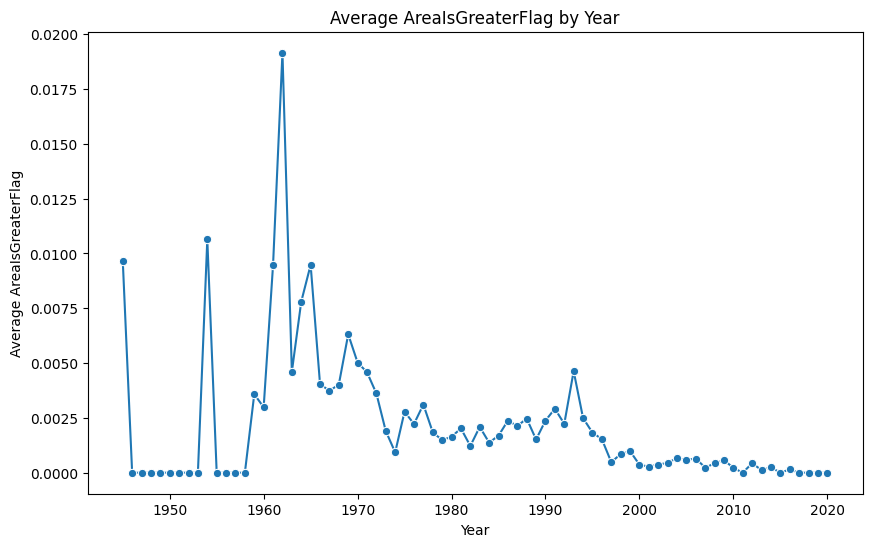

In [4]:
average_area_flag = df.groupby('BuildingYear')['AreaIsGreaterFlag'].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(data=average_area_flag, x='BuildingYear', y='AreaIsGreaterFlag', marker='o')
plt.title('Average AreaIsGreaterFlag by Year')
plt.xlabel('Year')
plt.ylabel('Average AreaIsGreaterFlag')

plt.show()

Construções mais antigas também tendem a ter uma Área maior do que 2000m², i.e., são maiores do que construções mais recentes e isso influência mais no preço. Isso também pode ser observado na correlação de -0.33 entre BuildingYear e Area;

### TimeToNearestStation

In [11]:
df[df["TimeToNearestStation"]=="1H30-2H"][["MinTimeToNearestStation", "MaxTimeToNearestStation"]]

,MinTimeToNearestStation,MaxTimeToNearestStation
10375,90.0,120.0
92444,90.0,120.0
101954,90.0,120.0
112875,90.0,120.0
139015,90.0,120.0
...,...,...
396971,90.0,120.0
396974,90.0,120.0
397017,90.0,120.0
399734,90.0,120.0


TimeToNearestStation deveria ser a média entre MinTimeToNearestStation e MaxTimeToNearestStation. Essas duas variáveis estão formatadas corretamente em minutos. Porém, em alguns casos, o TimeToNearestStation está como um período no formato (MinTimetoNearestStation - MaxTimeToNearestStation);

Uma forma de corrigir isso é apenas fazer a média de MaxTimeToNearestStation e MinTimeToNearestStation para recriá-lo da forma correta;

In [12]:
df["TimeToNearestStation"] = (df["MinTimeToNearestStation"] + df["MaxTimeToNearestStation"])/2

Vamos plotar novamente o Heatmap:

In [13]:
num_attributes = df.select_dtypes(include=['int64', 'float64'])

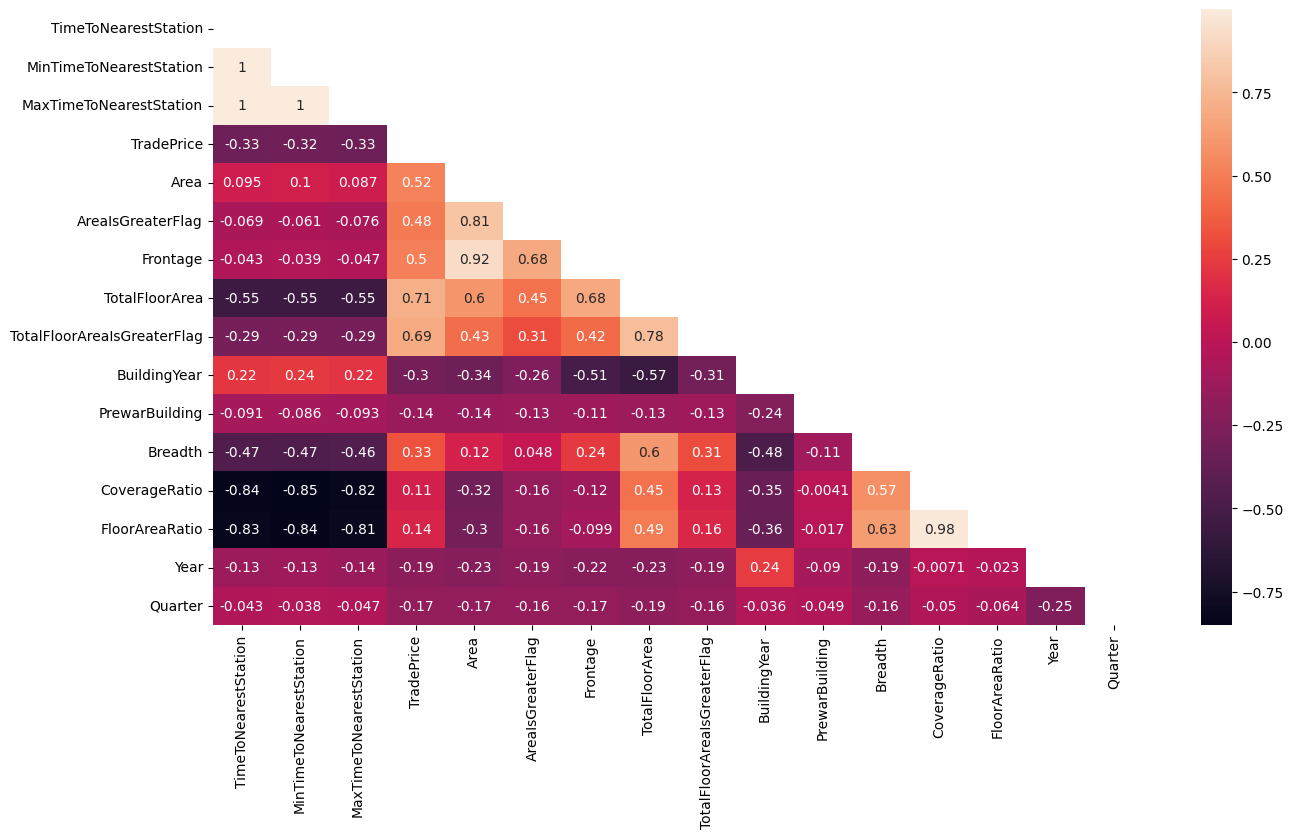

In [14]:
plot_heatmap(num_attributes)

Algumas variáveis com muita correlação com outras serão excluídas, mantendo aquelas com maior correlação com a variável alvo e/ou mantendo as que fazem mais sentido.

Para a variável Quarter vamos aplicar uma transformação cíclica, para capturar a sazonalidade trimestral.

In [15]:
cols = {'Quarter': 4, # quarter transformation
}

for period, cycle in cols.items():
    nature_encode(df, period, cycle)

In [16]:
df.columns

Index(['Type', 'Region', 'MunicipalityCode', 'Prefecture', 'Municipality',
       'DistrictName', 'NearestStation', 'TimeToNearestStation',
       'MinTimeToNearestStation', 'MaxTimeToNearestStation', 'TradePrice',
       'FloorPlan', 'Area', 'AreaIsGreaterFlag', 'LandShape', 'Frontage',
       'FrontageIsGreaterFlag', 'TotalFloorArea',
       'TotalFloorAreaIsGreaterFlag', 'BuildingYear', 'PrewarBuilding',
       'Structure', 'Use', 'Purpose', 'Direction', 'Classification', 'Breadth',
       'CityPlanning', 'CoverageRatio', 'FloorAreaRatio', 'Period', 'Year',
       'Quarter', 'Renovation', 'Quarter_sin', 'Quarter_cos'],
      dtype='object')

In [17]:
numerical_variables_selected = [
    "TimeToNearestStation",
    "Area",
    "BuildingYear",
    "CoverageRatio",
    "FloorAreaRatio",
    "Year",
    "Quarter_cos",
    "Quarter_sin",
]

In [18]:
df[numerical_variables_selected].isna().mean()

TimeToNearestStation    0.025798
Area                    0.000000
BuildingYear            0.226967
CoverageRatio           0.014548
FloorAreaRatio          0.014548
Year                    0.000000
Quarter_cos             0.000000
Quarter_sin             0.000000
dtype: float64

In [19]:
df[numerical_variables_selected]

,TimeToNearestStation,Area,BuildingYear,CoverageRatio,FloorAreaRatio,Year,Quarter_cos,Quarter_sin
0,4.0,30,2013.0,80.0,500.0,2019,-1.836970e-16,-1.000000e+00
1,4.0,80,2007.0,80.0,500.0,2019,-1.836970e-16,-1.000000e+00
2,2.0,110,2018.0,80.0,500.0,2019,-1.000000e+00,1.224647e-16
3,1.0,50,1976.0,80.0,700.0,2019,-1.000000e+00,1.224647e-16
4,4.0,65,2007.0,80.0,500.0,2019,-1.000000e+00,1.224647e-16
...,...,...,...,...,...,...,...,...
406570,NaN,500,NaN,70.0,200.0,2007,6.123234e-17,1.000000e+00
406571,NaN,115,NaN,70.0,200.0,2007,6.123234e-17,1.000000e+00
406572,NaN,230,NaN,70.0,200.0,2008,-1.836970e-16,-1.000000e+00
406573,NaN,175,NaN,70.0,200.0,2007,1.000000e+00,-2.449294e-16


### 2.2. Categorical Variables

In [20]:
cat_attributes = df.select_dtypes(exclude=['int64', 'float64', 'bool'])

In [21]:
cat_attributes.columns

Index(['Type', 'Region', 'MunicipalityCode', 'Prefecture', 'Municipality',
       'DistrictName', 'NearestStation', 'FloorPlan', 'LandShape',
       'FrontageIsGreaterFlag', 'Structure', 'Use', 'Purpose', 'Direction',
       'Classification', 'CityPlanning', 'Period', 'Renovation'],
      dtype='object')

In [22]:
cat_attributes.isna().mean().sort_values(ascending=False)

Purpose                  0.612049
Renovation               0.590479
FloorPlan                0.561874
Classification           0.461765
Direction                0.455746
LandShape                0.455692
Region                   0.454703
Use                      0.240755
Structure                0.216978
CityPlanning             0.009410
NearestStation           0.004250
Period                   0.000000
Type                     0.000000
DistrictName             0.000000
Municipality             0.000000
Prefecture               0.000000
MunicipalityCode         0.000000
FrontageIsGreaterFlag    0.000000
dtype: float64

In [23]:
cat_attributes[
    [
        "Type",
        "MunicipalityCode",
        "Municipality",
        "DistrictName",
        "CityPlanning",
    ]
]

,Type,MunicipalityCode,Municipality,DistrictName,CityPlanning
0,"Pre-owned Condominiums, etc.",13101,Chiyoda Ward,Iidabashi,Commercial Zone
1,"Pre-owned Condominiums, etc.",13101,Chiyoda Ward,Iidabashi,Commercial Zone
2,Residential Land(Land and Building),13101,Chiyoda Ward,Iidabashi,Commercial Zone
3,Residential Land(Land and Building),13101,Chiyoda Ward,Iidabashi,Commercial Zone
4,"Pre-owned Condominiums, etc.",13101,Chiyoda Ward,Iidabashi,Commercial Zone
...,...,...,...,...,...
406570,Residential Land(Land Only),13421,Ogasawara Village,Chichijima,Non-divided City Planning Area
406571,Residential Land(Land Only),13421,Ogasawara Village,Chichijima,Non-divided City Planning Area
406572,Residential Land(Land Only),13421,Ogasawara Village,Hahajima,Non-divided City Planning Area
406573,Residential Land(Land Only),13421,Ogasawara Village,Hahajima,Non-divided City Planning Area


In [ ]:
#TODO: Change locations.csv to a table in the database -> Populate it with geopy;

In [24]:
df_locations = pd.read_csv("locations.csv")
df = df.merge(df_locations, on="DistrictName", how="left")

In [25]:
categorical_variables_selected = [
    "Type", # tipo de residência, parece ser uma boa variável
    # "CityPlanning" # uso dos distritos pela lei de planejamento urbano, parece ser uma boa variável
    
]

In [26]:
df.columns

Index(['Type', 'Region', 'MunicipalityCode', 'Prefecture', 'Municipality',
       'DistrictName', 'NearestStation', 'TimeToNearestStation',
       'MinTimeToNearestStation', 'MaxTimeToNearestStation', 'TradePrice',
       'FloorPlan', 'Area', 'AreaIsGreaterFlag', 'LandShape', 'Frontage',
       'FrontageIsGreaterFlag', 'TotalFloorArea',
       'TotalFloorAreaIsGreaterFlag', 'BuildingYear', 'PrewarBuilding',
       'Structure', 'Use', 'Purpose', 'Direction', 'Classification', 'Breadth',
       'CityPlanning', 'CoverageRatio', 'FloorAreaRatio', 'Period', 'Year',
       'Quarter', 'Renovation', 'Quarter_sin', 'Quarter_cos', 'Latitude',
       'Longitude'],
      dtype='object')

In [27]:
categorical_variables_selected

['Type']

In [28]:
numerical_variables_selected.extend(['Latitude',
       'Longitude'])

In [29]:
numerical_variables_selected

['TimeToNearestStation',
 'Area',
 'BuildingYear',
 'CoverageRatio',
 'FloorAreaRatio',
 'Year',
 'Quarter_cos',
 'Quarter_sin',
 'Latitude',
 'Longitude']

# 3. Train-Test split

In [30]:
from sklearn.model_selection import train_test_split, cross_validate

Antes de qualquer outra modificação nos dados, vamos separar em treino e teste, para prevenir qualquer data leakage. Além disso, quando formos treinar os modelos, será utilizado cross-validation. 

In [31]:
# variaveis que serao usadas no modelo + variavel alvo (TradePrice) + DistrictName (que será usado pra tratar algumas variáveis nulas)
selected_variables = numerical_variables_selected + categorical_variables_selected + ["TradePrice", "DistrictName", "MunicipalityCode"] 

In [32]:
y = df["TradePrice"].copy()

In [33]:
X_train, X_test, y_train, y_test = train_test_split(df[selected_variables], y, test_size=0.2, random_state=0, shuffle=True)

# 4. Preprocessing

### 4.1. NaN treatment 

In [34]:
X_train[selected_variables]

,TimeToNearestStation,Area,BuildingYear,CoverageRatio,FloorAreaRatio,Year,Quarter_cos,Quarter_sin,Latitude,Longitude,Type,TradePrice,DistrictName,MunicipalityCode
3060,4.0,15,2004.0,80.0,700.0,2015,1.000000e+00,-2.449294e-16,35.675002,139.783445,"Pre-owned Condominiums, etc.",19000000,Shinkawa,13102
239670,8.0,25,2006.0,80.0,400.0,2008,1.000000e+00,-2.449294e-16,35.666255,139.775565,"Pre-owned Condominiums, etc.",13000000,Chuo,13114
165571,5.0,45,1992.0,60.0,300.0,2015,6.123234e-17,1.000000e+00,35.749219,139.715892,"Pre-owned Condominiums, etc.",28000000,Takinogawa,13117
218510,10.0,120,1985.0,40.0,80.0,2013,6.123234e-17,1.000000e+00,35.680048,139.619625,Residential Land(Land and Building),12000000,Takaidohigashi,13115
64370,12.0,60,2000.0,50.0,100.0,2014,1.000000e+00,-2.449294e-16,35.628006,139.673448,Residential Land(Land and Building),70000000,Kakinokizaka,13110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359783,NaN,560,NaN,NaN,NaN,2018,-1.000000e+00,1.224647e-16,34.069485,139.553822,Forest Land,340000,Tsubota,13381
358083,45.0,135,2016.0,50.0,100.0,2016,1.000000e+00,-2.449294e-16,35.778899,139.330760,Residential Land(Land and Building),22000000,Nagaoka,13303
152315,6.0,125,NaN,60.0,150.0,2006,6.123234e-17,1.000000e+00,35.653266,139.709595,Residential Land(Land Only),130000000,Higashigotanda,13109
117952,7.0,55,2005.0,80.0,200.0,2005,1.000000e+00,-2.449294e-16,35.700379,139.805867,Residential Land(Land and Building),41000000,Sumida,13107


In [35]:
X_train[selected_variables].isna().mean().sort_values(ascending=False)

BuildingYear            0.226794
Latitude                0.104984
Longitude               0.104984
TimeToNearestStation    0.026028
CoverageRatio           0.014471
FloorAreaRatio          0.014471
Area                    0.000000
Year                    0.000000
Quarter_cos             0.000000
Quarter_sin             0.000000
Type                    0.000000
TradePrice              0.000000
DistrictName            0.000000
MunicipalityCode        0.000000
dtype: float64

- **BuildingYear**: Substituir pela média do ano, agrupado por DistrictName
- **TimeToNearestStation**: Substituir pela mediana do ano, agrupado por DistrictName
- **CoverageRatio**: Substituir pela mediana do ano, agrupado por DistrictName
- **FloorAreaRatio**: Substituir pela mediana do ano, agrupado por DistrictName
- **Latitude**: Substituir pela mediana do ano, agrupado por MunicipalityCode
- **Longitude**: Substituir pela mediana do ano, agrupado por MunicipalityCode

Obs: Para o Latitude e Longitude foi agrupado por MunicipalityCode, porque é justamente o DistrictName que gera essas colunas, e se está nuilo seguirá nulo obviamente.

In [36]:
X_train[selected_variables].isna().mean().sort_values(ascending=False)

BuildingYear            0.226794
Latitude                0.104984
Longitude               0.104984
TimeToNearestStation    0.026028
CoverageRatio           0.014471
FloorAreaRatio          0.014471
Area                    0.000000
Year                    0.000000
Quarter_cos             0.000000
Quarter_sin             0.000000
Type                    0.000000
TradePrice              0.000000
DistrictName            0.000000
MunicipalityCode        0.000000
dtype: float64

In [37]:
X_train["BuildingYear"] = X_train["BuildingYear"].fillna(
    X_train.groupby("DistrictName")["BuildingYear"].transform("mean")
)
X_train["TimeToNearestStation"] = X_train["TimeToNearestStation"].fillna(
    X_test.groupby("DistrictName")["TimeToNearestStation"].transform("median")
)
X_train["CoverageRatio"] = X_train["CoverageRatio"].fillna(
    X_train.groupby("DistrictName")["CoverageRatio"].transform("median")
)
X_train["FloorAreaRatio"] = X_train["FloorAreaRatio"].fillna(
    X_train.groupby("DistrictName")["FloorAreaRatio"].transform("median")
)
X_train["Latitude"] = X_train["Latitude"].fillna(
    X_train.groupby("MunicipalityCode")["Latitude"].transform("median")
)
X_train["Longitude"] = X_train["Longitude"].fillna(
    X_train.groupby("MunicipalityCode")["Longitude"].transform("median")
)

In [38]:
X_train[selected_variables].isna().mean().sort_values(ascending=False)

TimeToNearestStation    0.026028
Latitude                0.001257
Longitude               0.001257
CoverageRatio           0.000443
FloorAreaRatio          0.000443
BuildingYear            0.000209
Area                    0.000000
Year                    0.000000
Quarter_cos             0.000000
Quarter_sin             0.000000
Type                    0.000000
TradePrice              0.000000
DistrictName            0.000000
MunicipalityCode        0.000000
dtype: float64

Ainda temos alguns valores nulos, para esses casos vamos só substituir pela mediana da coluna mesmo:

In [39]:
X_train["BuildingYear"] = X_train["BuildingYear"].fillna(
    X_train["BuildingYear"].median()
)
X_train["TimeToNearestStation"] = X_train["TimeToNearestStation"].fillna(
    X_train["TimeToNearestStation"].median()
)
X_train["Latitude"] = X_train["Latitude"].fillna(X_train["Latitude"].median())
X_train["Longitude"] = X_train["Longitude"].fillna(X_train["Longitude"].median())
X_train["CoverageRatio"] = X_train["CoverageRatio"].fillna(
    X_train["CoverageRatio"].median()
)
X_train["FloorAreaRatio"] = X_train["FloorAreaRatio"].fillna(
    X_train["FloorAreaRatio"].median()
)

In [40]:
X_train[selected_variables].isna().mean().sort_values(ascending=False)

TimeToNearestStation    0.0
Area                    0.0
BuildingYear            0.0
CoverageRatio           0.0
FloorAreaRatio          0.0
Year                    0.0
Quarter_cos             0.0
Quarter_sin             0.0
Latitude                0.0
Longitude               0.0
Type                    0.0
TradePrice              0.0
DistrictName            0.0
MunicipalityCode        0.0
dtype: float64

### 4.2. Variables Encoding (normalization/scaling)

In [41]:
cols = [
    "TimeToNearestStation",
    "Area",
    "BuildingYear",
    "CoverageRatio",
    "FloorAreaRatio",
    "Year",
    "Quarter_cos",
    "Quarter_sin",
    "Latitude",
    "Longitude",
    "Type",
]
X_train = X_train[cols]

### Categorical

In [42]:
one_hot = pd.get_dummies(X_train["Type"], drop_first=True, prefix="Type", dtype=int)
X_train = X_train.join(one_hot).drop("Type", axis=1)

### Numerical

Obs: Para os três modelos que vamos utilizar não é necessário normalizar as variáveis: Random Forest, XGBoost e LGBM, mas é interessante fazermos esse processo se fossemos utilizar uma rede neural, por exemplo.

In [43]:
scaler_nearest_station = MinMaxScaler()
scaler_area = MinMaxScaler()
scaler_building_year = MinMaxScaler()
scaler_coverage = MinMaxScaler()
scaler_floor = MinMaxScaler()
scaler_year = MinMaxScaler()
scaler_lat = MinMaxScaler()
scaler_long = MinMaxScaler()

X_train["TimeToNearestStation"] = scaler_nearest_station.fit_transform(X_train[["TimeToNearestStation"]])
X_train["Area"] = scaler_area.fit_transform(X_train[["Area"]])
X_train["BuildingYear"] = scaler_building_year.fit_transform(X_train[["BuildingYear"]])
X_train["CoverageRatio"] = scaler_coverage.fit_transform(X_train[["CoverageRatio"]])
X_train["FloorAreaRatio"] = scaler_floor.fit_transform(X_train[["FloorAreaRatio"]])
X_train["Year"] = scaler_year.fit_transform(X_train[["Year"]])
X_train["Latitude"] = scaler_lat.fit_transform(X_train[["Latitude"]])
X_train["Longitude"] = scaler_long.fit_transform(X_train[["Longitude"]])

In [44]:
X_train

,TimeToNearestStation,Area,BuildingYear,CoverageRatio,FloorAreaRatio,Year,Quarter_cos,Quarter_sin,Latitude,Longitude,Type_Forest Land,"Type_Pre-owned Condominiums, etc.",Type_Residential Land(Land Only),Type_Residential Land(Land and Building)
3060,0.038095,0.001002,0.786667,1.0,0.520,0.714286,1.000000e+00,-2.449294e-16,0.813453,0.829528,0,1,0,0
239670,0.076190,0.003006,0.813333,1.0,0.280,0.214286,1.000000e+00,-2.449294e-16,0.812669,0.828974,0,1,0,0
165571,0.047619,0.007014,0.626667,0.6,0.200,0.714286,6.123234e-17,1.000000e+00,0.820110,0.824781,0,1,0,0
218510,0.095238,0.022044,0.533333,0.2,0.024,0.571429,6.123234e-17,1.000000e+00,0.813906,0.818017,0,0,0,1
64370,0.114286,0.010020,0.733333,0.4,0.040,0.642857,1.000000e+00,-2.449294e-16,0.809239,0.821799,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359783,0.076190,0.110220,0.474286,0.8,0.120,0.928571,-1.000000e+00,1.224647e-16,0.669459,0.813394,1,0,0,0
358083,0.428571,0.025050,0.946667,0.4,0.040,0.785714,1.000000e+00,-2.449294e-16,0.822772,0.797720,0,0,0,1
152315,0.057143,0.023046,0.737579,0.6,0.080,0.071429,6.123234e-17,1.000000e+00,0.811504,0.824339,0,0,1,0
117952,0.066667,0.009018,0.800000,1.0,0.120,0.000000,1.000000e+00,-2.449294e-16,0.815729,0.831104,0,0,0,1


In [45]:
X_train.isna().sum()

TimeToNearestStation                        0
Area                                        0
BuildingYear                                0
CoverageRatio                               0
FloorAreaRatio                              0
Year                                        0
Quarter_cos                                 0
Quarter_sin                                 0
Latitude                                    0
Longitude                                   0
Type_Forest Land                            0
Type_Pre-owned Condominiums, etc.           0
Type_Residential Land(Land Only)            0
Type_Residential Land(Land and Building)    0
dtype: int64

### Target Variable

In [46]:
y_train = np.log1p(y_train) # Logarithm Transformation

# 5. Model Training

In [47]:
# Converter pra snake_case, porque alguns modelos não aceitam caracteres especiais
X_train.columns = [
    'time_to_nearest_station', 'area', 'building_year', 'coverage_ratio',
    'floor_area_ratio', 'year', 'quarter_cos', 'quarter_sin', 'latitude',
    'longitude', 'type_forest_land', 'type_pre_owned_condominiums_etc',
    'type_residential_land_land_only',
    'type_residential_land_land_and_building'
]


Reduzindo o número de variáveis, usando Random Forest como um seletor de variáveis

In [48]:
# rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train)

# importances = rf.feature_importances_

# feature_importances = pd.DataFrame({
#     'feature': X_train.columns,
#     'importance': importances
# })

# feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# print(feature_importances)

In [49]:
# final_selected_variables = [
#     "time_to_nearest_station",
#     "area",
#     "building_year",
#     "floor_area_ratio",
#     "year",
#     "latitude",
#     "longitude",
# ]


In [50]:
# X_train = X_train[final_selected_variables]

A classe `OptimizeRegressor` consegue otimizar 3 modelos diferentes: RandomForest, XGBoost e LGBM, salvando depois os melhores parâmetros num `json`.

Obs: A otimização é feita com base na métrica `RMSLE`, avaliando com cross-validation (K_fold=5)

### 5.1. Hyperparameter Optimization with Cross-Validation

### Random Forest

In [51]:
# rf_opt = OptimizeRegressor(
#     model_name="rf", n_trials=20, X_train=X_train, y_train=y_train
# )

# rf_opt.optimize()

### XGBoost

0.02000 - xgb_best_params_14_features.json

In [52]:
xgb_opt = OptimizeRegressor(
    model_name="xgb", n_trials=30, X_train=X_train, y_train=y_train
)

xgb_opt.optimize()

[I 2024-05-17 16:04:18,508] A new study created in memory with name: no-name-86461f38-7cd2-49ec-a392-986b809e3b2a
[I 2024-05-17 16:04:38,471] Trial 0 finished with value: 0.021017730550045584 and parameters: {'n_estimators': 1100, 'learning_rate': 0.065, 'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.6, 'colsample_bytree': 0.95}. Best is trial 0 with value: 0.021017730550045584.
[I 2024-05-17 16:06:37,403] Trial 1 finished with value: 0.02063857357312524 and parameters: {'n_estimators': 2800, 'learning_rate': 0.075, 'max_depth': 10, 'min_child_weight': 2, 'subsample': 0.95, 'colsample_bytree': 0.7}. Best is trial 1 with value: 0.02063857357312524.
[I 2024-05-17 16:06:55,014] Trial 2 finished with value: 0.02051614229150347 and parameters: {'n_estimators': 1300, 'learning_rate': 0.06999999999999999, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.6, 'colsample_bytree': 0.8}. Best is trial 2 with value: 0.02051614229150347.
[I 2024-05-17 16:07:53,618] Trial 3 finished with v

### LGBM

In [53]:
lgbm_opt = OptimizeRegressor(
    model_name="lgbm", n_trials=30, X_train=X_train, y_train=y_train
)
lgbm_opt.optimize()

[I 2024-05-17 15:42:21,654] A new study created in memory with name: no-name-fcd0fe00-3e1f-43e9-8157-10c3b13d2a40
[I 2024-05-17 15:43:48,742] Trial 0 finished with value: 0.02056402592074822 and parameters: {'n_estimators': 2700, 'learning_rate': 0.01, 'max_depth': 9, 'num_leaves': 100}. Best is trial 0 with value: 0.02056402592074822.
[I 2024-05-17 15:44:01,295] Trial 1 finished with value: 0.022630141555725746 and parameters: {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 12, 'num_leaves': 80}. Best is trial 0 with value: 0.02056402592074822.
[I 2024-05-17 15:44:29,749] Trial 2 finished with value: 0.02021614029134565 and parameters: {'n_estimators': 1200, 'learning_rate': 0.04, 'max_depth': 12, 'num_leaves': 124}. Best is trial 2 with value: 0.02021614029134565.
[I 2024-05-17 15:45:09,491] Trial 3 finished with value: 0.02013437868731533 and parameters: {'n_estimators': 2400, 'learning_rate': 0.04, 'max_depth': 10, 'num_leaves': 84}. Best is trial 3 with value: 0.02013437

### 5.2. Fitting the best model

### Random Forest

In [ ]:
# rf_best_params = read_json("/parameters/best_params_rf.json")
# rf_best_params["verbose"] = -1
# rf_best_params["n_jobs"] = -1
# rf_best_params["random_state"] = 42

### XGBoost

In [ ]:
xgb_best_params = read_json("/parameters/best_params_xgb.json")
xgb_best_params["n_jobs"] = -1
xgb_best_params["random_state"] = 42

In [54]:
xgb_model = XGBRegressor(**xgb_best_params)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.75, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.035, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

### LGBM

In [ ]:
lgbm_best_params = read_json("/parameters/best_params_lgbm.json")
lgbm_best_params["verbosity"] = -1
lgbm_best_params["n_jobs"] = -1
lgbm_best_params["random_state"] = 42

In [55]:
model = LGBMRegressor(**lgbm_best_params)
model.fit(X_train, y_train)

LGBMRegressor(learning_rate=0.05, max_depth=10, n_estimators=2600, n_jobs=-1,
              num_leaves=112, random_state=42, verbosity=-1)

#### Testar remover algumas variáveis

- Temos 14 colunas, o que é bastante pro volume de dados.

# Evaluating results in Test

Precisa aplicar novamente o mesmo processamento que foi feito para X_train.

In [55]:
X_test["BuildingYear"] = X_test["BuildingYear"].fillna(
    X_test.groupby("DistrictName")["BuildingYear"].transform("mean")
)
X_test["TimeToNearestStation"] = X_test["TimeToNearestStation"].fillna(
    X_test.groupby("DistrictName")["TimeToNearestStation"].transform("median")
)
X_test["CoverageRatio"] = X_test["CoverageRatio"].fillna(
    X_test.groupby("DistrictName")["CoverageRatio"].transform("median")
)
X_test["FloorAreaRatio"] = X_test["FloorAreaRatio"].fillna(
    X_test.groupby("DistrictName")["FloorAreaRatio"].transform("median")
)
X_test["Latitude"] = X_test["Latitude"].fillna(
    X_test.groupby("MunicipalityCode")["Latitude"].transform("median")
)
X_test["Longitude"] = X_test["Longitude"].fillna(
    X_test.groupby("MunicipalityCode")["Longitude"].transform("median")
)

In [56]:
X_test["BuildingYear"] = X_test["BuildingYear"].fillna(
    X_test["BuildingYear"].median()
)
X_test["TimeToNearestStation"] = X_test["TimeToNearestStation"].fillna(
    X_test["TimeToNearestStation"].median()
)
X_test["Latitude"] = X_test["Latitude"].fillna(X_test["Latitude"].median())
X_test["Longitude"] = X_test["Longitude"].fillna(X_test["Longitude"].median())
X_test["CoverageRatio"] = X_test["CoverageRatio"].fillna(
    X_test["CoverageRatio"].median()
)
X_test["FloorAreaRatio"] = X_test["FloorAreaRatio"].fillna(
    X_test["FloorAreaRatio"].median()
)

In [57]:
cols = [
    "TimeToNearestStation",
    "Area",
    "BuildingYear",
    "CoverageRatio",
    "FloorAreaRatio",
    "Year",
    "Quarter_cos",
    "Quarter_sin",
    "Latitude",
    "Longitude",
    "Type",
]
X_test = X_test[cols]

In [58]:
one_hot = pd.get_dummies(X_test["Type"], drop_first=True, prefix="Type", dtype=int)
X_test = X_test.join(one_hot).drop("Type", axis=1)

In [59]:
scaler_nearest_station = MinMaxScaler()
scaler_area = MinMaxScaler()
scaler_building_year = MinMaxScaler()
scaler_coverage = MinMaxScaler()
scaler_floor = MinMaxScaler()
scaler_year = MinMaxScaler()
scaler_lat = MinMaxScaler()
scaler_long = MinMaxScaler()

X_test["TimeToNearestStation"] = scaler_nearest_station.fit_transform(X_test[["TimeToNearestStation"]])
X_test["Area"] = scaler_area.fit_transform(X_test[["Area"]])
X_test["BuildingYear"] = scaler_building_year.fit_transform(X_test[["BuildingYear"]])
X_test["CoverageRatio"] = scaler_coverage.fit_transform(X_test[["CoverageRatio"]])
X_test["FloorAreaRatio"] = scaler_floor.fit_transform(X_test[["FloorAreaRatio"]])
X_test["Year"] = scaler_year.fit_transform(X_test[["Year"]])
X_test["Latitude"] = scaler_lat.fit_transform(X_test[["Latitude"]])
X_test["Longitude"] = scaler_long.fit_transform(X_test[["Longitude"]])

In [60]:
# Converter pra snake_case, porque alguns modelos não aceitam caracteres especiais
X_test.columns = [
    'time_to_nearest_station', 'area', 'building_year', 'coverage_ratio',
    'floor_area_ratio', 'year', 'quarter_cos', 'quarter_sin', 'latitude',
    'longitude', 'type_forest_land', 'type_pre_owned_condominiums_etc',
    'type_residential_land_land_only',
    'type_residential_land_land_and_building'
]


In [61]:
y_test = np.log1p(y_test) # Logarithm Transformation 

In [65]:
# X_test = X_test[final_selected_variables]

### **Predict**

In [63]:
predictions = xgb_model.predict(X_test)

In [64]:
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

In [65]:
# Voltando aos valores
comparison_df = comparison_df.assign(Actual=np.expm1(comparison_df['Actual']))
comparison_df = comparison_df.assign(Predicted=np.expm1(comparison_df['Predicted']))

In [66]:
comparison_df

,Actual,Predicted
164964,57000000.0,50416272.0
405628,18000000.0,16394887.0
36359,7000000.0,7555653.0
358112,16000000.0,13949742.0
396468,66000000.0,61091608.0
...,...,...
219310,36000000.0,26320316.0
322488,38000000.0,39806632.0
6057,45000000.0,32722690.0
38678,57000000.0,71520248.0


### Test Result

In [67]:
mape = mean_absolute_percentage_error(comparison_df["Actual"], comparison_df["Predicted"])
rmsle = np.sqrt(mean_squared_log_error(comparison_df["Actual"], comparison_df["Predicted"]))

In [68]:
# novo - xgboost
print(f"mape = {mape}")
print(f"rmsle = {rmsle}")

mape = 0.3945776229607925
rmsle = 0.3488141026159459


In [68]:
# novo - lgbm
print(f"mape = {mape}")
print(f"rmsle = {rmsle}")

mape = 0.5061042842893033
rmsle = 0.38223049708257556


In [65]:
print(f"mape = {mape}")
print(f"rmsle = {rmsle}")

mape = 0.3819359979784899
rmsle = 0.38348949713450664


In [60]:
comparison_df

,Actual,Predicted
164964,57000000.0,5.048309e+07
405628,18000000.0,1.735935e+07
36359,7000000.0,6.362006e+06
358112,16000000.0,1.017839e+07
396468,66000000.0,4.406585e+07
...,...,...
219310,36000000.0,2.777936e+07
322488,38000000.0,2.789517e+07
6057,45000000.0,3.161022e+07
38678,57000000.0,7.226326e+07
